# Cross-task generalization between MOU and rDCM 

This notebook examines group‑level convergence of effective connectivity across rDCM and MOU using cross‑model decoding (train on one, test on the other), showing both capture BOLD propagation dynamics similarly.

## Environment setup & index configuration

In [28]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stt

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import matplotlib.colors as colors
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap 

import seaborn as sb
from pandas.conftest import axis_1

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA


# Jupyter magic commands
%matplotlib inline

# Set plot style
plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = False


# Directories
#out_path = "../../../temp/results_MOU/"
data_path = Path('/home/INT/gilson.m/Neuro/projects/Nicolas_Gravel/MOU_DCM_v2_Nico/retNet/retNet/temp')
output_fig_pth = data_path / 'figs'

# Data numbers
n_rois = 24
n_sub = 156
n_cond = 3

# Index dictionary
conf = {
    'tasks'   : ['VFM','MOV','RST'],
# NEEDED?
#    'task'    : [
#               [0,1],     # retinotopy
#                [2,3,4,5], # movie watching
#                [6,7,8,9]  # resting state
#                ],
#    'flows'   : ['outflow', 'inflow'],

    'eccentricity'    : ['fovea','periph'],
    'eccen_rois'      : [
                        [0,2,4,6,8,10,12,14,16,18,20,22],   #  fovea
                        [1,3,5,7,9,11,13,15,17,19,21,23]    #  periph
                        ],
    'hierarchy'       : ['V1','V2','V3'],
    'hier_rois'       : [
                        [0,1,2,3,12,13,14,15],  # V1
                        [4,5,6,7,16,17,18,19],  # V2
                        [8,9,10,11,20,21,22,23] # V3
                        ],
    'hemisphere'      : ['left', 'right'],
    'hemis_rois'      : [
                        [0,1,2,3,4,5,6,7,8,9,10,11],            #  left
                        [12,13,14,15,16,17,18,19,20,21,22,23]   #  right
                        ],
    'pathway'         : ['ventral', 'dorsal'],
    'path_rois'       : [
                        [0,1,4,5,8,9,12,13,16,17,20,21],        #  ventral
                        [2,3,6,7,10,11,14,15,18,19,22,23]       #  dorsal
                        ]
    }

# create vectors with ecccentricity, hirearchy, hemisphere and pathway for all ROIs
eccentricity_index = np.zeros((n_rois))
for i, l in enumerate(conf['eccen_rois']):
    eccentricity_index[l] = i

hierarchy_index = np.zeros((n_rois))
for i, l in enumerate(conf['hier_rois']):
    hierarchy_index[l] = i

hemisphere_index = np.zeros((n_rois))
for i, l in enumerate(conf['hemis_rois']):
    hemisphere_index[l] = i

pathway_index = np.zeros((n_rois))
for i, l in enumerate(conf['path_rois']):
    pathway_index[l] = i

# labels and colors for plotting
label_cond = conf['tasks']
cond_colors = [[0.14, 0.30,  0.63],
               [0.17, 0.62, 0.76],
               [0.56, 0.83, 0.73]]

## Reorder ROIs to highlight topology of connections

In [15]:
# Reorder indices: foveal then parafoveal, for each hemisphere
#new_order = [0, 2, 4, 6, 8, 10, 1, 3, 5, 7, 9, 11,   # Left hemisphere
#             12, 14, 16, 18, 20, 22, 13, 15, 17, 19, 21, 23]  # Right hemisphere

# left / right hemisphere, then pathway (ventral vs dorsal), then eccentricity (fovea vs periphery)
new_order = [0, 4, 8, 1, 5, 9,          # left ventral
             2, 6, 10, 3, 7, 11,        # left dorsal
             12, 16, 20, 13, 17, 21,    # right ventral
             14, 18, 22, 15, 19, 23]    # right dorsal

# Original ROI labels (repeats for left/right hemisphere)
roi_labels = ['V1 vf', 'V1 vp', 'V1 df', 'V1 dp',
              'V2 vf', 'V2 vp', 'V2 df', 'V2 dp',
              'V3 vf', 'V3 vp', 'V3 df', 'V3 dp'] * 2

# Reordered labels
roi_labels_sorted = [roi_labels[i] for i in new_order]
print(roi_labels_sorted)

['V1 vf', 'V2 vf', 'V3 vf', 'V1 vp', 'V2 vp', 'V3 vp', 'V1 df', 'V2 df', 'V3 df', 'V1 dp', 'V2 dp', 'V3 dp', 'V1 vf', 'V2 vf', 'V3 vf', 'V1 vp', 'V2 vp', 'V3 vp', 'V1 df', 'V2 df', 'V3 df', 'V1 dp', 'V2 dp', 'V3 dp']


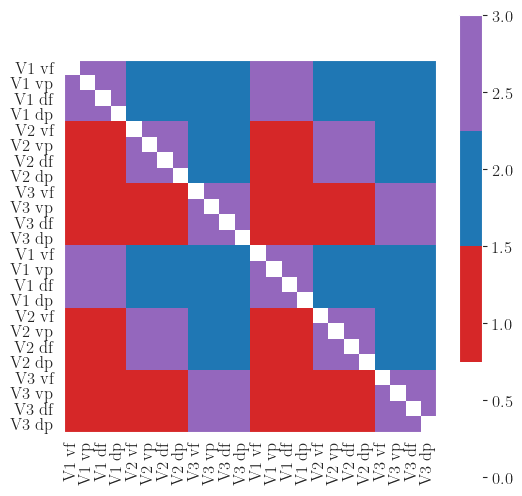

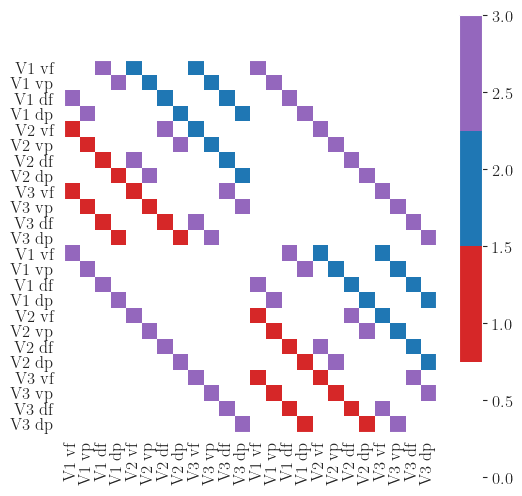

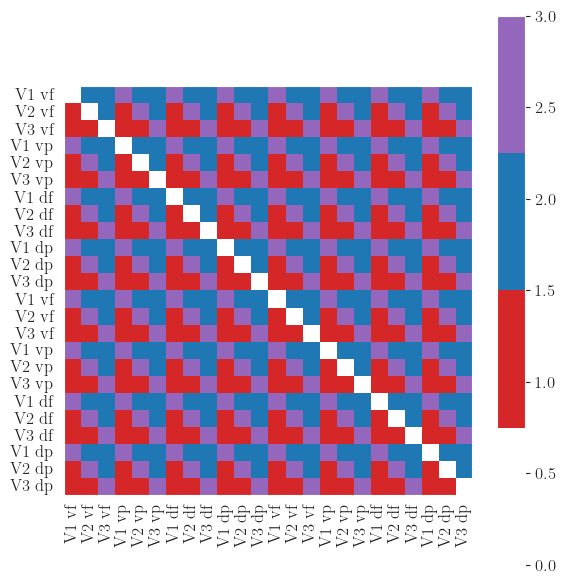

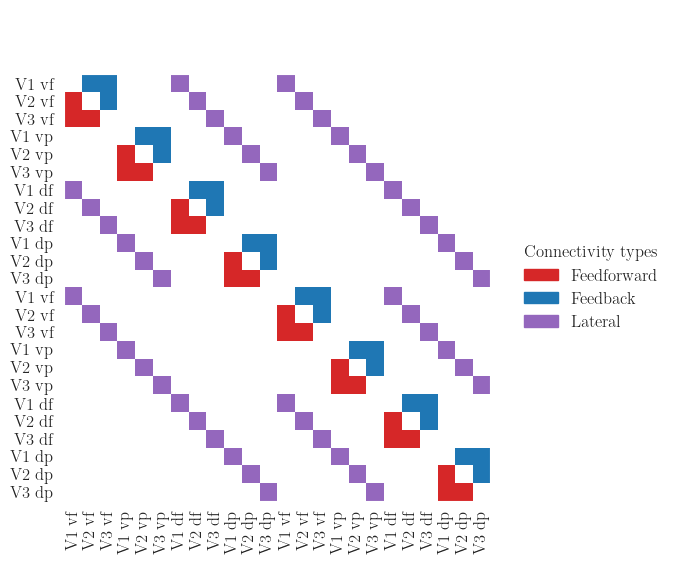

In [143]:
# link type
# 1 : feedforward (red)
# 2 : backforward (blue)
# 3 : lateral (purple)

cmap_conn = colors.LinearSegmentedColormap.from_list('topo_cmap', ['white', 'tab:red', 'tab:blue', 'tab:purple'], N=4)

EC_topo = np.zeros((n_rois, n_rois))
for roi_p in range(n_rois):  # source
    for roi_q in range(n_rois):  # target
        if roi_p != roi_q:  # skip diagonal
            if hierarchy_index[roi_p] < hierarchy_index[roi_q]:
                EC_topo[roi_p, roi_q] = 1
            elif hierarchy_index[roi_p] > hierarchy_index[roi_q]:
                EC_topo[roi_p, roi_q] = 2
            else:
                EC_topo[roi_p, roi_q] = 3

# plot matrices of connectivity types in original order
plt.figure(figsize=(6, 6))
plt.imshow(EC_topo.T, cmap=cmap_conn, vmin=0, vmax=3)
plt.colorbar()
plt.xticks(range(n_rois), roi_labels, rotation=90)
plt.yticks(range(n_rois), roi_labels)

# only specific connections now within same pathway (ventral versus dorsal)
# red: feedforward connections (ROIs of same hemisphere, same pathway, same eccentricity)
# blue: feeback connections (ROIs of same hemisphere, same pathway, same eccentricity)
# magenta: lateral inter-hemispheric homotopic interactions (ROIs with same hierarchy in addition to pathway and eccentricity)
# magenta: lateral inter-pathway homotopic interactions (ROIs with same hierarchy in addition to hemisphere and eccentricity)

EC_topo_backbone = np.zeros((n_rois, n_rois))
for roi_p in range(n_rois):  # source
    for roi_q in range(n_rois):  # target
        if roi_p != roi_q and eccentricity_index[roi_p] == eccentricity_index[roi_q] and hemisphere_index[roi_p] == \
                hemisphere_index[roi_q] and pathway_index[roi_p] == pathway_index[roi_q]:
            if hierarchy_index[roi_p] < hierarchy_index[roi_q]:
                EC_topo_backbone[roi_p, roi_q] = 1
            elif hierarchy_index[roi_p] > hierarchy_index[roi_q]:
                EC_topo_backbone[roi_p, roi_q] = 2
        if hemisphere_index[roi_p] != hemisphere_index[roi_q] and hierarchy_index[roi_p] == hierarchy_index[roi_q] and \
                eccentricity_index[roi_p] == eccentricity_index[roi_q] and pathway_index[roi_p] == pathway_index[roi_q]:
            EC_topo_backbone[roi_p, roi_q] = 3
        if pathway_index[roi_p] != pathway_index[roi_q] and hierarchy_index[roi_p] == hierarchy_index[roi_q] and \
                hemisphere_index[roi_p] == hemisphere_index[roi_q] and eccentricity_index[roi_p] == eccentricity_index[
            roi_q]:
            EC_topo_backbone[roi_p, roi_q] = 3

plt.figure(figsize=(6, 6))
plt.imshow(EC_topo_backbone.T, cmap=cmap_conn, vmin=0, vmax=3)
plt.colorbar()
plt.xticks(range(n_rois), roi_labels, rotation=90)
plt.yticks(range(n_rois), roi_labels)


# reordered
EC_topo_reord = EC_topo[new_order, :][:, new_order]
EC_topo_backbone_reord = EC_topo_backbone[new_order, :][:, new_order]

plt.figure(figsize=(6, 6))
plt.imshow(EC_topo_reord.T, cmap=cmap_conn, vmin=0, vmax=3)
plt.colorbar()
plt.xticks(range(n_rois), roi_labels_sorted, rotation=90)
plt.yticks(range(n_rois), roi_labels_sorted)
plt.tight_layout()

fig, axs = plt.subplots(1, 2, width_ratios=(3, 1), figsize=(7, 6))
# matrix plot
im = axs[0].imshow(EC_topo_backbone_reord.T, cmap=cmap_conn, vmin=0, vmax=3)
#fig.colorbar(im, ax=axs[0])
axs[0].set_xticks(range(n_rois), roi_labels_sorted, rotation=90)
axs[0].set_yticks(range(n_rois), roi_labels_sorted)
# legend
color_list = ['tab:red', 'tab:blue', 'tab:purple'] # same as above
labels = ['Feedforward', 'Feedback', 'Lateral']
axs[1].axis('off')
handles = [patches.Patch(color=color, label=label) for color, label in zip(color_list, labels)]
axs[1].legend(handles=handles, loc='center', frameon=False, title='Connectivity types', ncol=1)
# save figure
fig.tight_layout()
fig.savefig(output_fig_pth / 'backbone.png', dpi=300)

### Load MOU Results

In [45]:
data_MOU_path = data_path / 'results_MOU'
model = 'new_2021'

# Load the MOU results
print("Loading results from: ", data_MOU_path)
model_fit = np.load(data_MOU_path / f'Fit_{model}.npy')
EC_MOU = np.load(data_MOU_path / f'J_mod_{model}.npy')
EC_MOU[:,:,np.eye(n_rois, dtype=bool)] = 0.0

# Print shapes of all arrays to determine the correct axis for subject removal
print("Current shapes before removal:")
print(f"model_fit: {model_fit.shape}")
print(f"J_mod: {EC_MOU.shape}")

# check dimensions
assert EC_MOU.shape == (n_cond, n_sub, n_rois, n_rois)

Loading results from:  /home/INT/gilson.m/Neuro/projects/Nicolas_Gravel/MOU_DCM_v2_Nico/retNet/retNet/temp/results_MOU
Current shapes before removal:
model_fit: (3, 156)
J_mod: (3, 156, 24, 24)


## Detect subjects with all-zero matrices in any condition

NOT USEFUL ANYMORE

In [ ]:
# Detect subjects with all-zero OFF-DIAGONAL elements in any condition
problematic_subjects_any_zero = []
num_subjects = J_mod.shape[1]
num_conditions = J_mod.shape[0]

for i_sub in range(num_subjects):
    is_problematic = False
    for cond_idx in range(num_conditions):
        matrix = J_mod[cond_idx, i_sub, :, :]
        # Create a copy and zero out the diagonal to check only off-diagonal elements
        off_diag_matrix = matrix.copy()
        np.fill_diagonal(off_diag_matrix, 0)

        # Check if all off-diagonal elements are zero (or very close to zero)
        if np.all(np.abs(off_diag_matrix) < 1e-10):
            print(f"Subject {i_sub}, Condition {cond_idx}: All off-diagonal elements are zero")
            is_problematic = True
            break
    if is_problematic:
        problematic_subjects_any_zero.append(i_sub)

print(f"\nSubjects with all-zero off-diagonal matrices in at least one condition: {problematic_subjects_any_zero}")
print(f"Total problematic subjects: {len(problematic_subjects_any_zero)}")

# Remove problematic subjects from all arrays (using the list from detection)
# Sort in descending order to avoid index shifting
problematic_subjects_sorted = sorted(problematic_subjects_any_zero, reverse=True)

# Remove from arrays using the correct subject axis for each
model_fit = np.delete(model_fit, problematic_subjects_sorted, axis=1)
J_mod = np.delete(J_mod, problematic_subjects_sorted, axis=1)


# Print shapes to verify removal
print("Shapes after removing problematic subjects:")
print(f"model_fit: {model_fit.shape}")
print(f"J_mod_array: {J_mod.shape}")

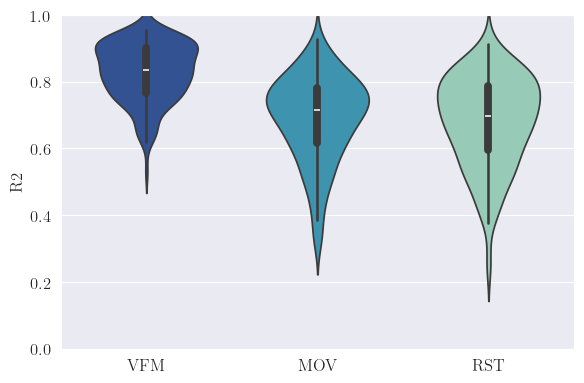

In [146]:
df_model_fit = pd.DataFrame()
for i_cond, cond in enumerate(label_cond):
    df_tmp = pd.DataFrame()
    df_tmp['R2'] = model_fit[i_cond,:]
    df_tmp['cond'] = cond
    df_model_fit = pd.concat((df_model_fit, df_tmp))

fig, ax = plt.subplots(figsize=(6, 4))
ax.grid(True)
sb.violinplot(data=df_model_fit, x='cond', y='R2', hue='cond', palette=cond_colors, width=0.6, ax=ax)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel('')
fig.tight_layout()

## Load rDCM results

In [46]:
model = 'rDCM_2024' 

data_rDCM_path = data_path / 'results_rDCM'

#out_path = "../../../temp/results_rDCM/"
print("Loading results from:", data_rDCM_path)

# Load pre-averaged results directly
EC_rDCM = np.load(data_rDCM_path / f'EC_avg_{model}.npy')

print('EC_avg_dcm shape:', EC_rDCM.shape)      # Expected: (3, 156, 24, 24)

Loading results from: /home/INT/gilson.m/Neuro/projects/Nicolas_Gravel/MOU_DCM_v2_Nico/retNet/retNet/temp/results_rDCM
EC_avg_dcm shape: (3, 156, 24, 24)


## Normalize EC matrices 

To make EC matrices comparable across participants and conditions, each matrix is scaled by its L1 norm. This preserves relative differences in connection strengths while removing variations in overall magnitude.

In [147]:
def normalize_connectivity_matrices(EC_data, normalization_type='L1', verbose=True):
    """
    Normalize effective connectivity matrices using L1 or L2 normalization.
    
    Parameters
    ----------
    EC_data : ndarray
        Effective connectivity data with shape (n_conditions, n_subjects, n_rois, n_rois)
    normalization_type : str, optional
        Type of normalization to apply: 'L1' or 'L2' (default: 'L2')
        - 'L1': Normalize by sum of values (Manhattan norm)
        - 'L2': Normalize by Euclidean norm
    verbose : bool, optional
        Whether to print normalization information (default: True)
    
    Returns
    -------
    EC_normalized : ndarray
        Normalized connectivity matrices with same shape as input
    norm_name : str
        Name of the normalization method used
    
    Notes
    -----
    - Diagonal elements are set to zero before and after normalization
    - If the norm is zero, the matrix is returned unchanged
    """

    if normalization_type == 'L1':
        EC_norm = (np.abs(EC_data)).sum(axis=(2,3), keepdims=True)
    elif normalization_type == 'L2':
        EC_norm = (EC_data**2).sum(axis=(2,3), keepdims=True)
    else:
        EC_norm = np.ones_like(EC_data)

    # normalize
    EC_normalized = EC_data / EC_norm

    # Print information if verbose
    if verbose:
        print(f'EC shape: {EC_normalized.shape}, normalized using {normalization_type} norm')
    
    return EC_normalized


In [148]:
EC_normed_MOU = normalize_connectivity_matrices(
    EC_data=EC_MOU,
    normalization_type='L1',
    verbose=True
)

EC_normed_rDCM = normalize_connectivity_matrices(
    EC_data=EC_rDCM,
    normalization_type='L1',
    verbose=True
)

EC shape: (3, 156, 24, 24), normalized using L1 norm
EC shape: (3, 156, 24, 24), normalized using L1 norm


In [158]:
def plot_connectivity_matrix(EC_data, order, model_name, output_filename,
                             add_boxes=False,
                             effect_size_threshold=0.1,
                             colorbar_label='EC',
                             use_latex=True):
    """
    Plot connectivity matrices with effect sizes for multiple conditions.

    Parameters
    ----------
    EC_data : ndarray
        Effective connectivity data with shape (n_conditions, n_subjects, n_rois, n_rois)
    order : array
        Order of ROIs
    model_name : str
        Model name (e.g., 'new_2021') to determine colormap normalization
    output_filename : str
        Full path for saving the output figure
    add_boxes : boolean
        Add boxes of backbone connections
    effect_size_threshold : float, optional
        Threshold for displaying effect sizes (default: 0.1)
    colorbar_label : str, optional
        Label for the colorbar (default: 'EC')
    use_latex : bool, optional
        Whether to use LaTeX rendering for text (default: True)

    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure object
    ax : array of matplotlib.axes.Axes
        Array of axes objects
    effect_sizes : ndarray
        Computed effect sizes with shape (n_conditions, n_rois, n_rois)
    """
    # Set plot style
    if use_latex:
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.weight'] = 'bold'
        plt.rcParams['font.family'] = 'serif'

    # ROI labels: new version with left then right hemisphere
    # for each hemisphere: ventral then dorsal
    # within pathway: fovea then periphery
    rois_sorted_orig = [
        'V1 vf', 'V1 vp', 'V1 df', 'V1 dp',
        'V2 vf', 'V2 vp', 'V2 df', 'V2 dp',
        'V3 vf', 'V3 vp', 'V3 df', 'V3 dp',
        'V1 vf', 'V1 vp', 'V1 df', 'V1 dp',
        'V2 vf', 'V2 vp', 'V2 df', 'V2 dp',
        'V3 vf', 'V3 vp', 'V3 df', 'V3 dp'
    ]
    ''' should become for more recent version
    rois_sorted = [
        'V1 vf', 'V2 vf', 'V3 vf', 'V1 vp', 'V2 vp', 'V3 vp',
        'V1 df', 'V2 df', 'V3 df', 'V1 dp', 'V2 dp', 'V3 dp',
        'V1 vf', 'V2 vf', 'V3 vf', 'V1 vp', 'V2 vp', 'V3 vp',
        'V1 df', 'V2 vf', 'V3 df', 'V1 dp', 'V2 dp', 'V3 dp',
    ]'''

    # Cohen's d effect size function
    def cohen_d(group1, group2):
        """Calculate Cohen's d effect size between two groups."""
        mean1, mean2 = np.nanmean(group1), np.nanmean(group2)
        std1, std2 = np.nanstd(group1, ddof=1), np.nanstd(group2, ddof=1)
        n1, n2 = len(group1), len(group2)
        pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
        d = (mean1 - mean2) / pooled_std
        return d

    # Get dimensions and reorder
    n_cond, n_sub, n_rois, _ = EC_data.shape
    EC_data = EC_data[:,:,order,:][:,:,:,order]
    rois_sorted = [rois_sorted_orig[i] for i in order]

    # Calculate effect sizes
    effect_sizes = np.zeros((n_cond, n_rois, n_rois))
    for i_cond in range(n_cond):
        for roi_p in range(n_rois):
            for roi_q in range(n_rois):
                effect_sizes[i_cond, roi_p, roi_q] = cohen_d(
                    EC_data[i_cond, :, roi_p, roi_q],
                    EC_data[i_cond, :, :, :].flatten()
                )

    # Create figure
    fig, ax = plt.subplots(1, n_cond, figsize=(18, 6), dpi=300, facecolor="w")

    # Calculate color limits (symmetric)
#    EC_min = np.min(np.nanmean(EC_data, axis=1).flatten())
#    EC_max = np.max(np.nanmean(EC_data, axis=1).flatten())
    EC_abs_max = np.max(np.abs(np.nanmean(EC_data, axis=1).flatten()))

    # Plot each condition
    for i_cond in range(n_cond):
        # Create colormap normalization
        divnorm = colors.TwoSlopeNorm(vmin=-EC_abs_max, vcenter=0, vmax=EC_abs_max)
        im = ax[i_cond].imshow(
            np.mean(EC_data[i_cond, :, :, :], axis=0).T,
            norm=divnorm, cmap='BrBG_r'
        )

        # Add effect size annotations
        for roi_p in range(n_rois):
            for roi_q in range(n_rois):
                if effect_sizes[i_cond, roi_p, roi_q] >= effect_size_threshold:
                    if roi_p != roi_q:  # Skip diagonal
                        txt = ax[i_cond].text(
                            roi_p, roi_q,
                            f'{effect_sizes[i_cond, roi_p, roi_q]:.1f}',
                            ha='center', va='center', color='black',
                            fontsize=8, rotation=30
                        )
                        txt.set_path_effects([
                            PathEffects.withStroke(linewidth=2, foreground='w')
                        ])

        # Set labels and ticks
        ax[i_cond].set_xlabel('Source ROI', fontsize=14)
        ax[i_cond].set_xticks(np.arange(len(rois_sorted)))
        ax[i_cond].set_xticklabels(labels=rois_sorted, rotation=90)
        if i_cond == 0:
            ax[i_cond].set_ylabel('Target ROI', fontsize=14)
        ax[i_cond].set_yticks(np.arange(len(rois_sorted)))
        ax[i_cond].set_yticklabels(labels=rois_sorted, rotation=0)

        # Hide y-labels for subplots after the first
        if i_cond != 0:
            ax[i_cond].set_yticks(np.arange(len(rois_sorted)))
            ax[i_cond].set_yticklabels([''] * len(rois_sorted))

        # Set title
        ax[i_cond].set_title(conf['tasks'][i_cond], fontsize=24)

        # Add colorbar to first subplot
        if i_cond == 0:
            cbar = plt.colorbar(
                im,
#                cax=fig.add_axes([0.32, -0.07, 0.12, 0.024]),
                cax=fig.add_axes([0.96, 0.2, 0.02, 0.6]), # vertical colorbar
                extend='both',
                orientation='vertical'
#                orientation='horizontal'
            )
            cbar.ax.tick_params(labelsize=8)
            cbar.set_label(f'EC (${colorbar_label}$)', fontsize=12)

        if add_boxes:
            # add rectangles
            l = 3
            for i in range(8): # V1-V2-V3 for ROIs with same pathway (ventral vs dorsal), excentricity (fovea vs periphery), hemisphere
                x_low = l * i - 0.5
                ax[i_cond].add_patch(plt.Rectangle((x_low, x_low), l, l, ls="--", lw=2, ec=[0,0,0], fc="none"))
            for i in range(12):
                x_low = i - 0.5
                x_high = x_low + 12
                ax[i_cond].add_patch(plt.Rectangle((x_low, x_high), 1, 1, ls="--", lw=2, ec=[0.3,0.3,0.3], fc="none"))
                ax[i_cond].add_patch(plt.Rectangle((x_high, x_low), 1, 1, ls="--", lw=2, ec=[0.3,0.3,0.3], fc="none"))
            for j in range(2):
                for i in range(6):
                    x_low = i - 0.5 + 12 * j
                    x_high = x_low + 6
                    ax[i_cond].add_patch(plt.Rectangle((x_low, x_high), 1, 1, ls="--", lw=2, ec=[0.6,0.6,0.6], fc="none"))
                    ax[i_cond].add_patch(plt.Rectangle((x_high, x_low), 1, 1, ls="--", lw=2, ec=[0.6,0.6,0.6], fc="none"))

    # Save figure
    plt.savefig(
        output_filename,
        transparent=None,
        dpi='figure',
        format='png',
        facecolor='auto',
        edgecolor='auto',
        bbox_inches='tight'
    )

    return fig, ax, effect_sizes

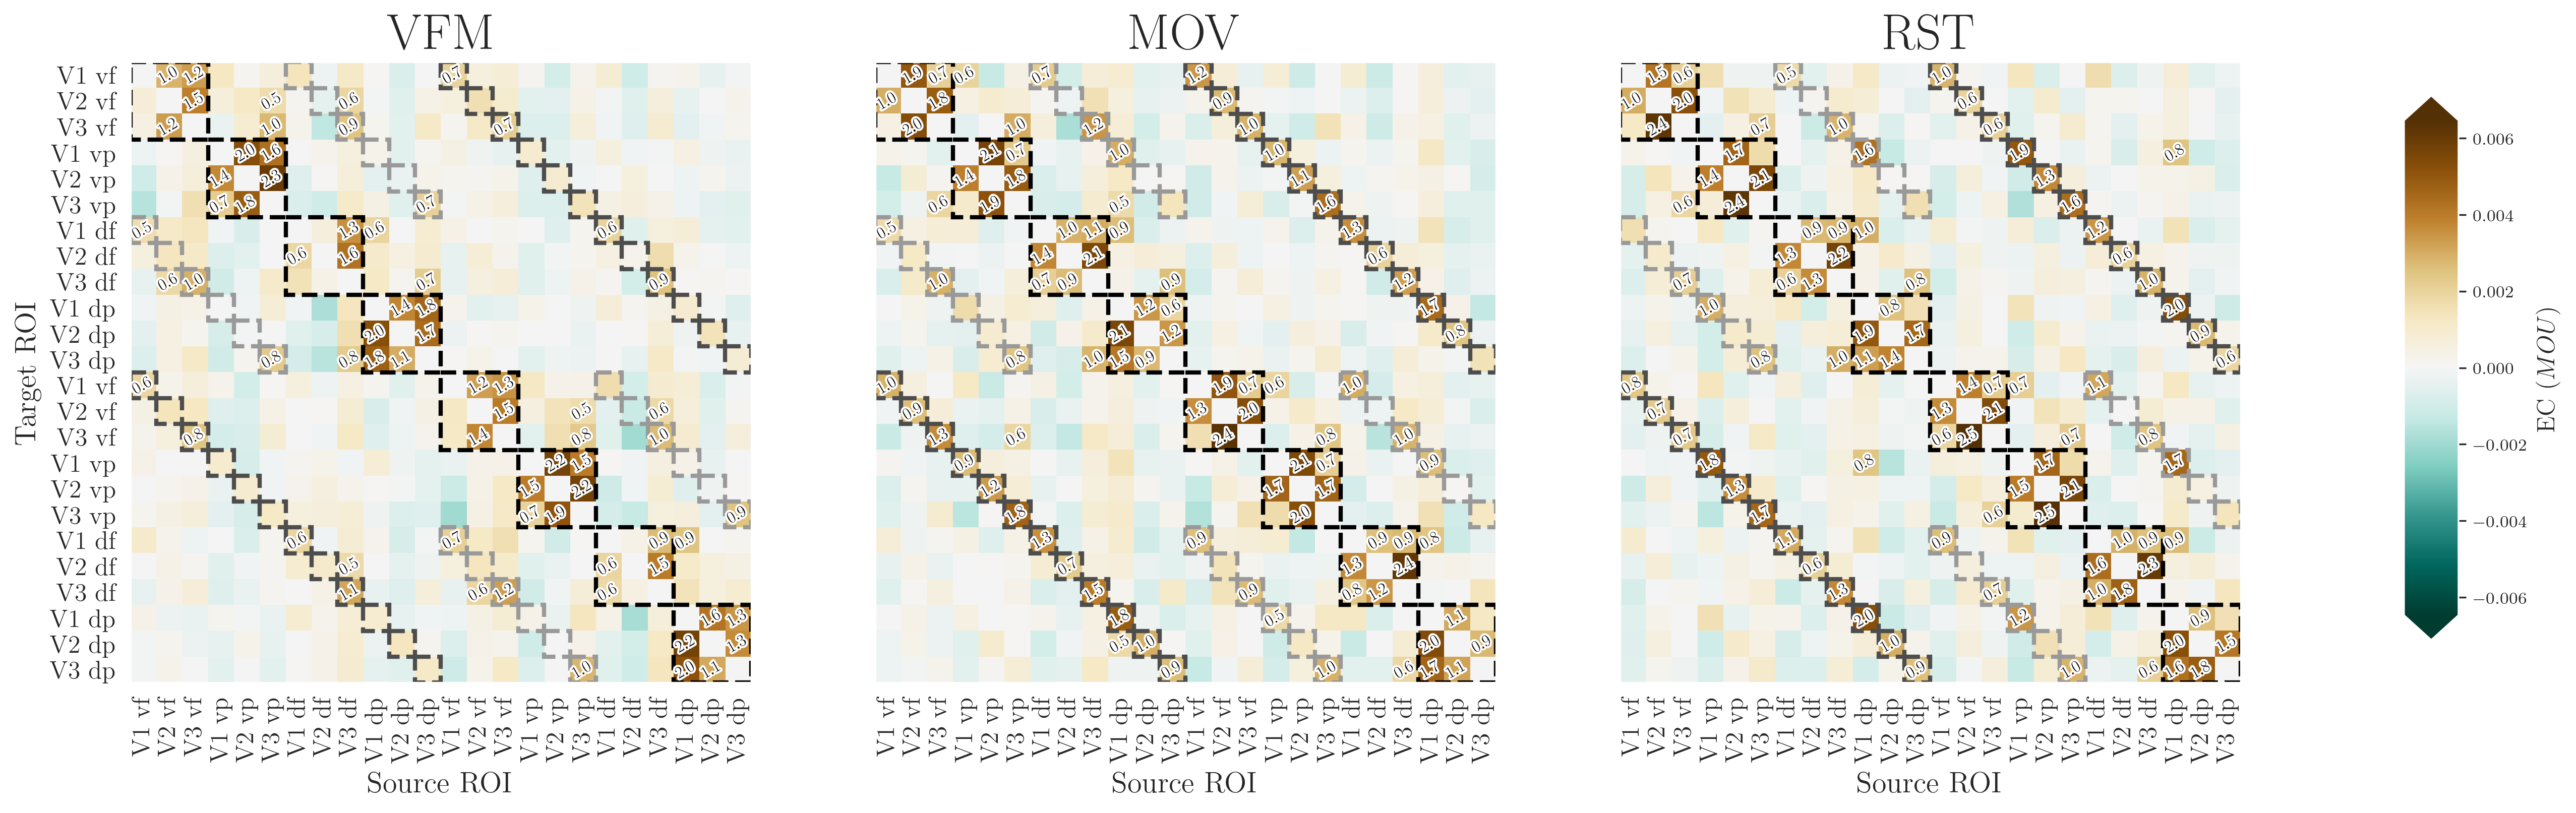

In [159]:
fig, ax, effect_sizes = plot_connectivity_matrix(
    EC_data=EC_normed_MOU,
    order=new_order,
    model_name=model,
    output_filename=output_fig_pth / 'retNet24_MOU.png',
    add_boxes=True,
    effect_size_threshold=0.5, # MG 0.1
    colorbar_label='MOU'
)

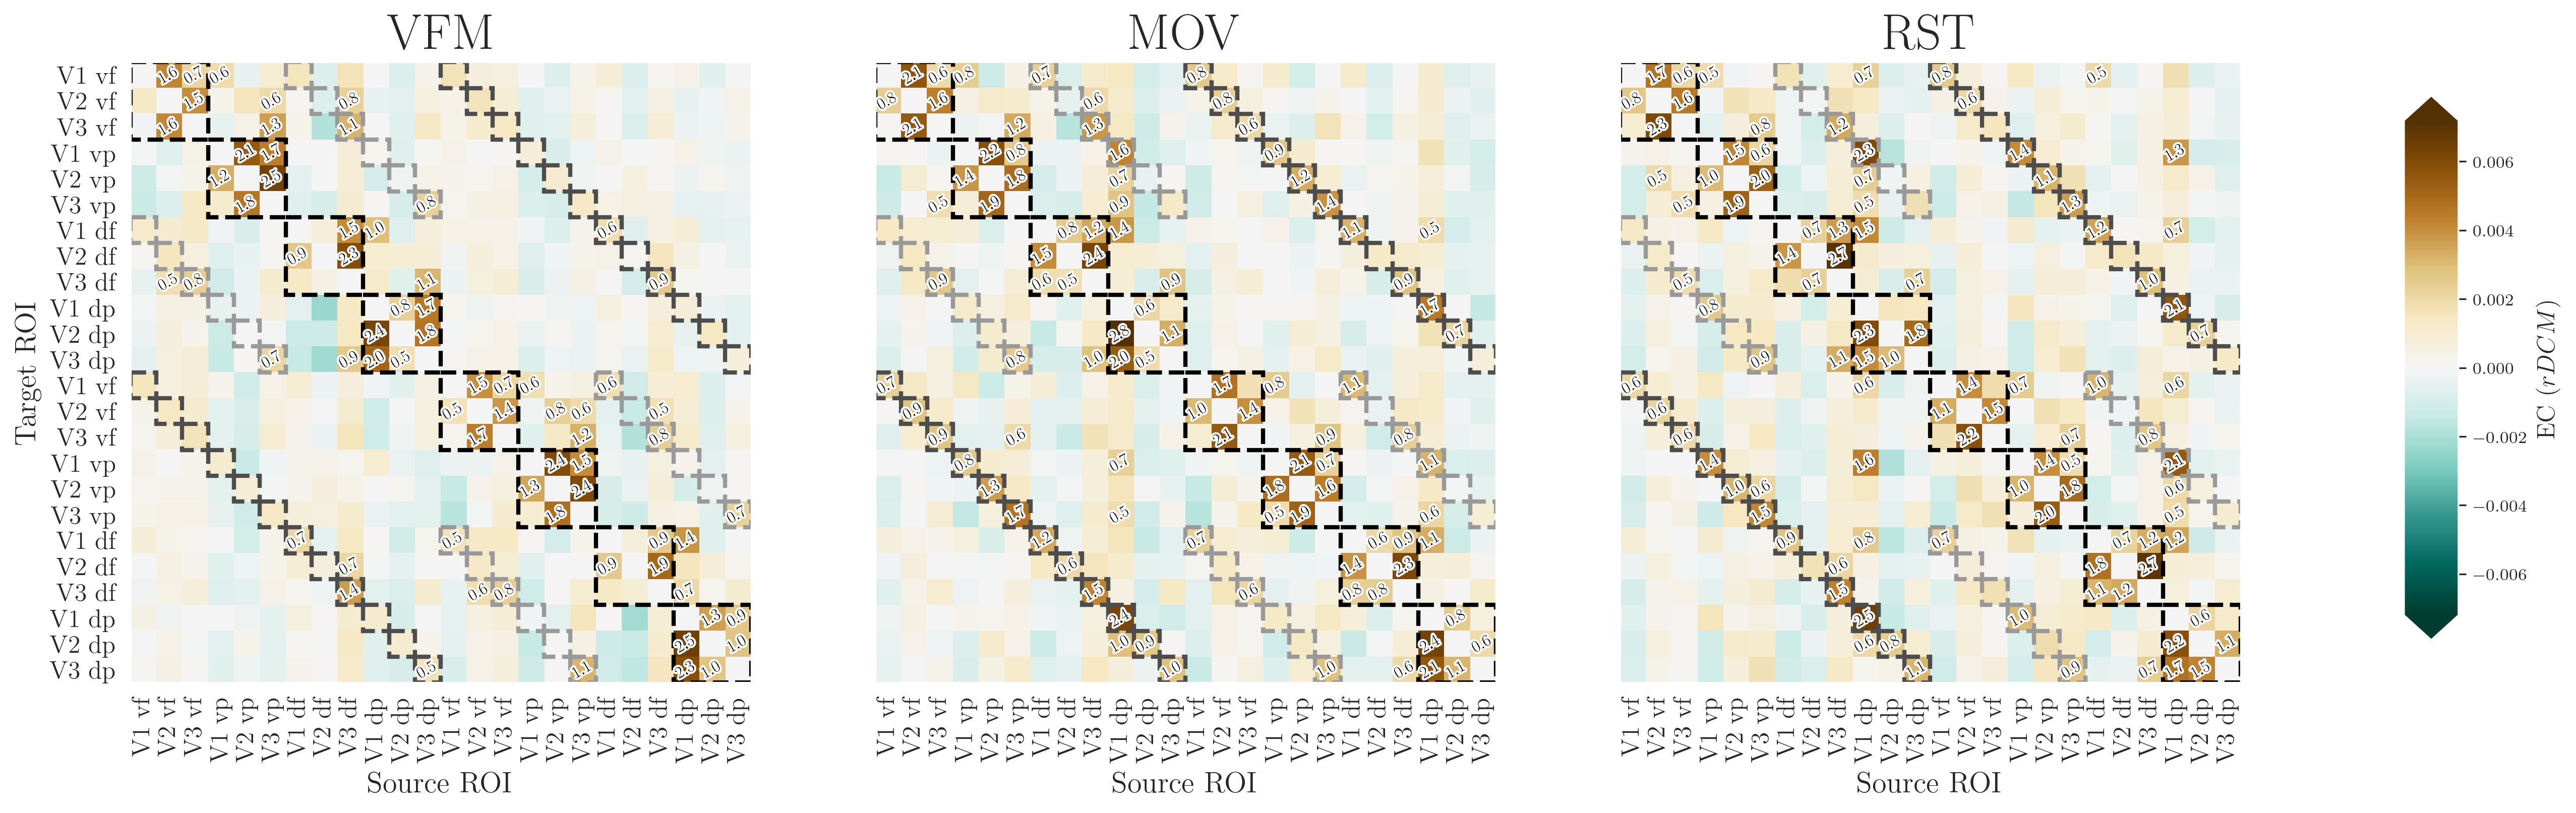

In [160]:
fig, ax, effect_sizes = plot_connectivity_matrix(
    EC_data=EC_normed_rDCM,
    order=new_order,
    model_name=model,
    output_filename=output_fig_pth / 'retNet24_rDCM.png',
    add_boxes=True,
    effect_size_threshold=0.5, # MG 0.1
    colorbar_label='rDCM'
)

## Alignment between MOU-EC and rDCM-EC



PearsonRResult(statistic=np.float64(0.9701958910082672), pvalue=np.float64(2.6080764502996075e-163))
PearsonRResult(statistic=np.float64(0.9760664669165137), pvalue=np.float64(1.266804199548543e-175))
PearsonRResult(statistic=np.float64(0.9665755624834316), pvalue=np.float64(6.847234668094014e-157))
PearsonRResult(statistic=np.float64(0.9504472364607911), pvalue=np.float64(3.794779468219089e-147))
PearsonRResult(statistic=np.float64(0.9583218236231698), pvalue=np.float64(1.197012022851747e-157))
PearsonRResult(statistic=np.float64(0.9392720354072563), pvalue=np.float64(7.199656157828353e-135))


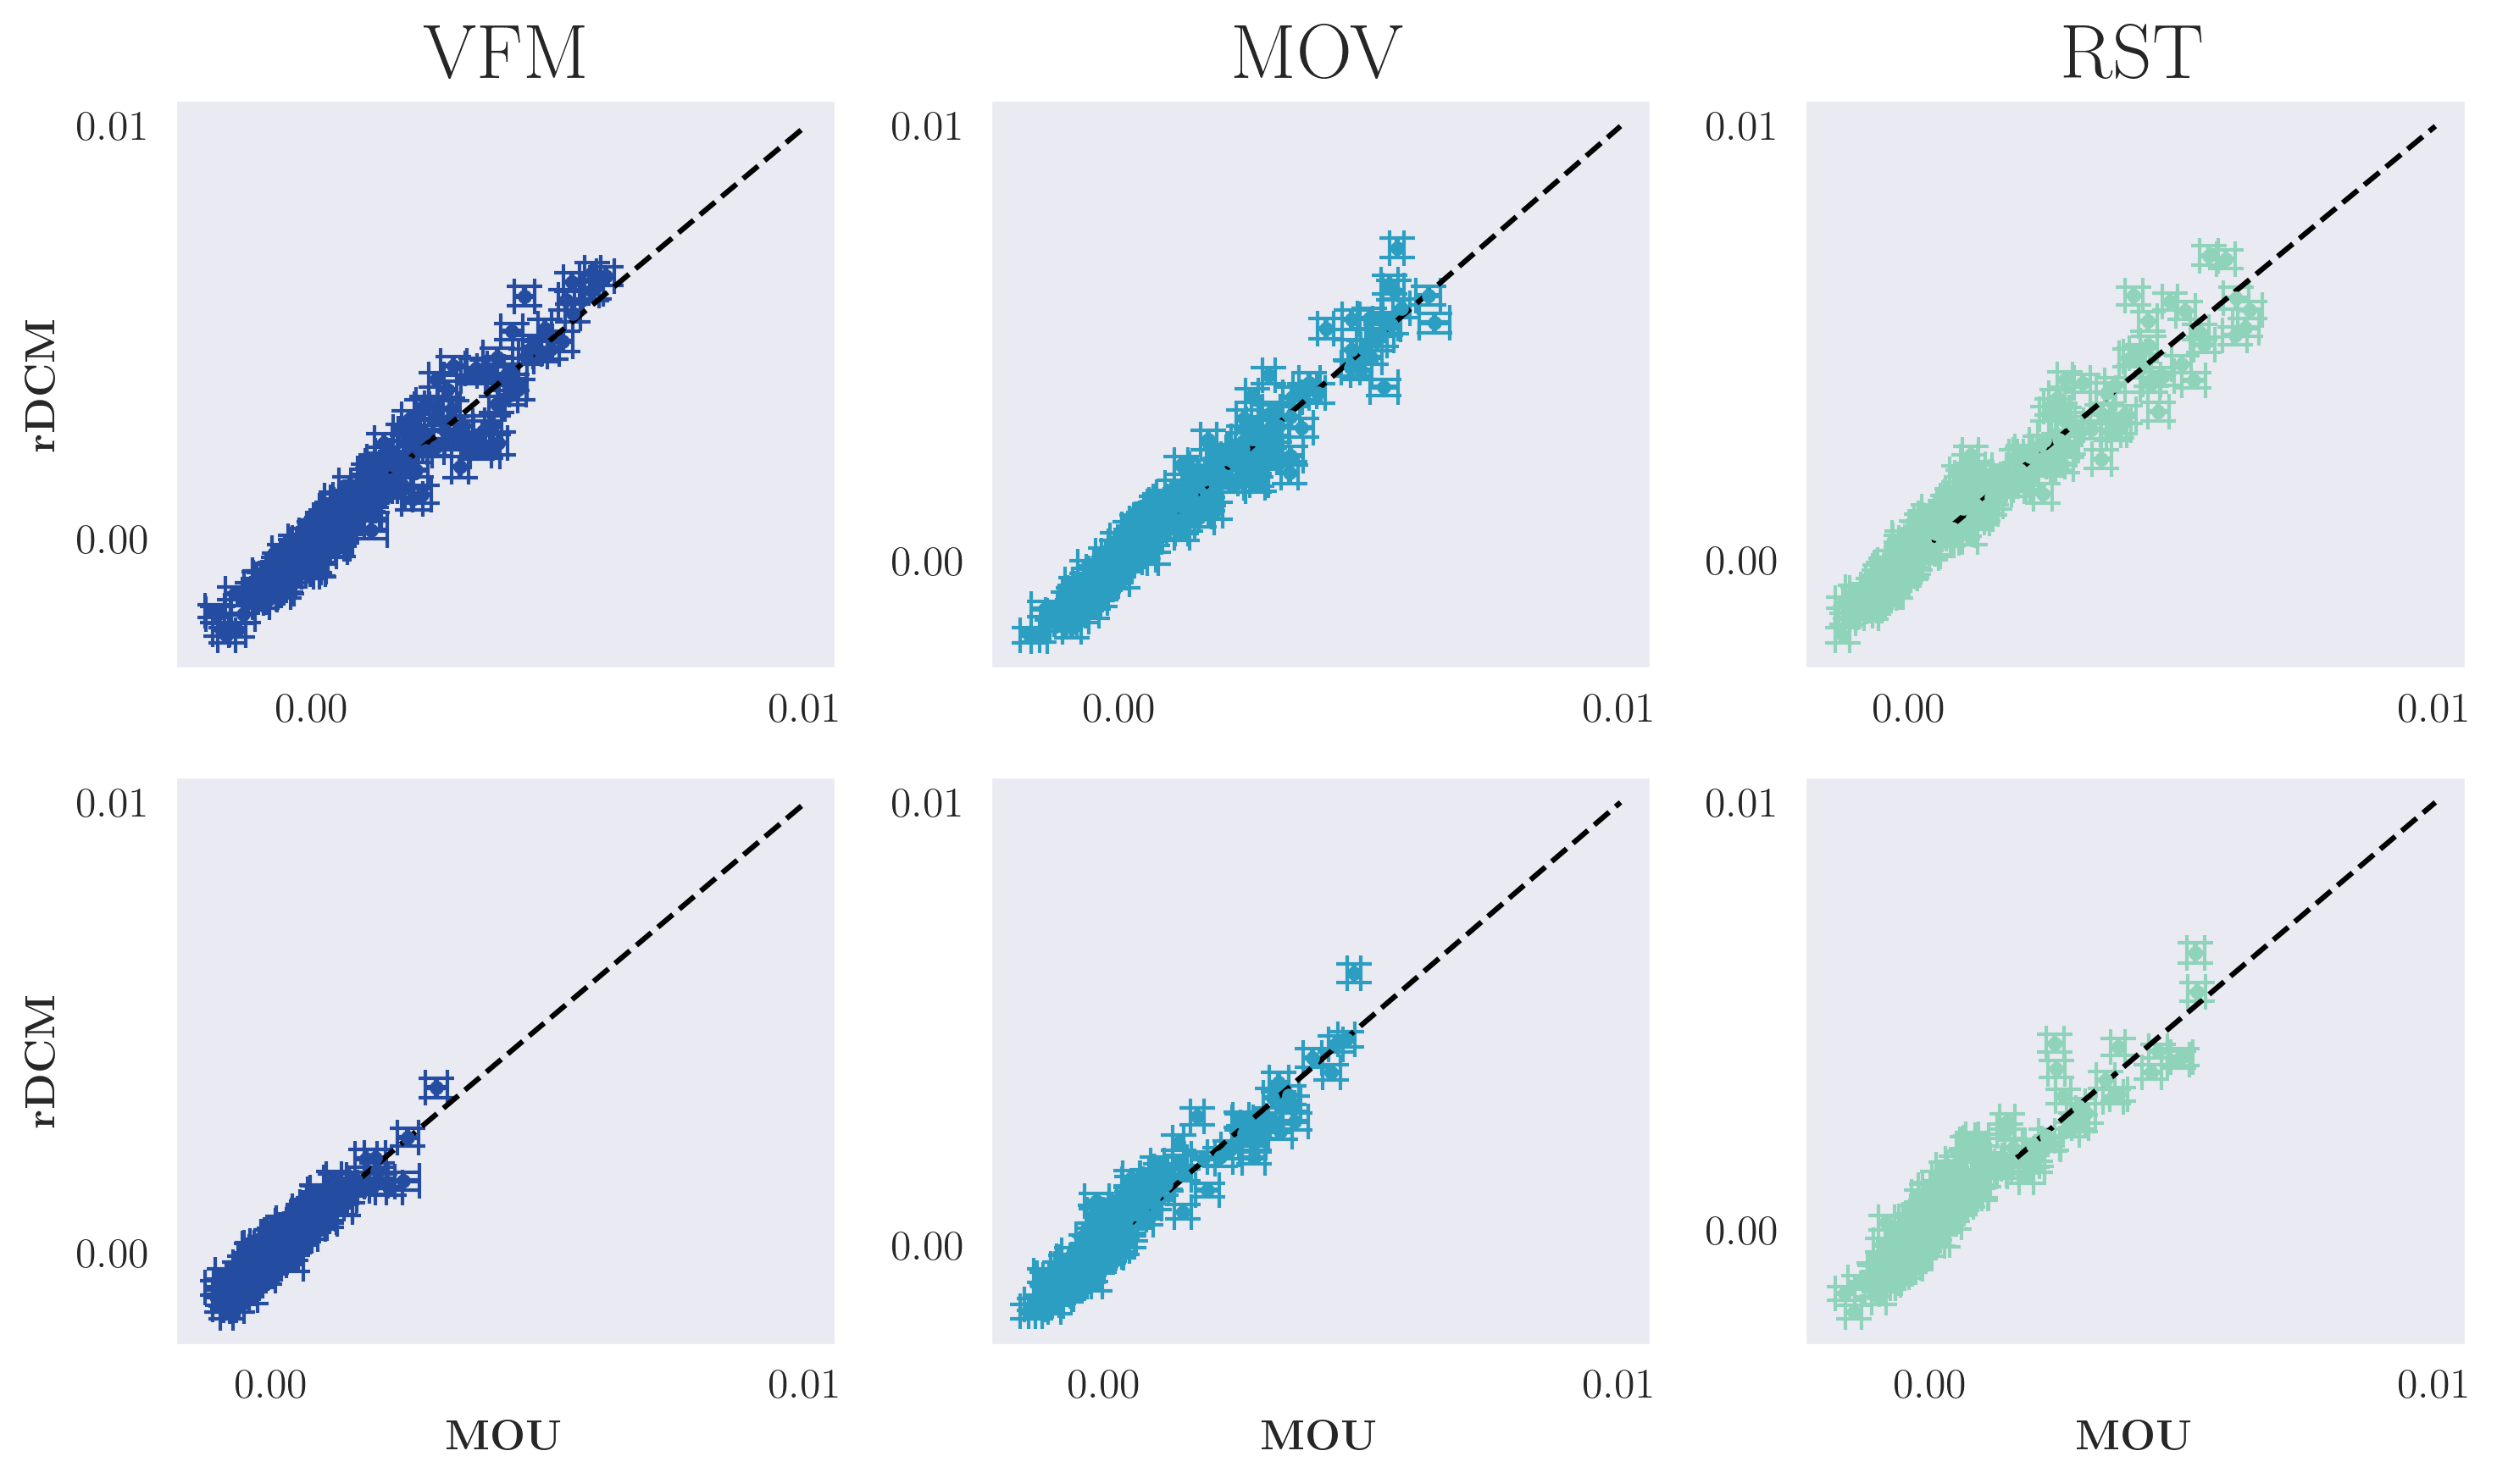

In [225]:
mask_same_hemis = np.zeros((n_rois,n_rois), dtype=bool)
mask_inter_hemis = np.zeros((n_rois,n_rois), dtype=bool)
for i in range(12):
    for j in range(12):
        if i != j:
            mask_same_hemis[i,j] = True
            mask_same_hemis[i+12,j+12] = True
        mask_inter_hemis[i,j+12] = True
        mask_inter_hemis[i+12,j] = True

# Assuming EC_mou and EC_dcm are already defined
fig, axs = plt.subplots(2,3, figsize=(10,6), dpi=300, facecolor="w")

# get weights between ROIS from same hemisphere
for i_mask, mask in enumerate([mask_same_hemis, mask_inter_hemis]):

    m_EC_MOU = np.mean(EC_normed_MOU[:,:,mask], axis=1)
    sem_EC_MOU = stt.sem(EC_normed_MOU[:,:,mask], axis=1)
    m_EC_rDCM = np.mean(EC_normed_rDCM[:,:,mask], axis=1)
    sem_EC_rDCM = stt.sem(EC_normed_rDCM[:,:,mask], axis=1)


    for i_cond in range(n_cond):
        if i_mask == 0 :
            axs[i_mask,i_cond].set_title(conf['tasks'][i_cond], fontsize=22)

        axs[i_mask,i_cond].errorbar(m_EC_MOU[i_cond,:], m_EC_rDCM[i_cond,:], xerr=sem_EC_MOU[i_cond,:], yerr=sem_EC_rDCM[i_cond,:], fmt='.', capsize=5, color=cond_colors[i_cond])
        axs[i_mask,i_cond].plot((0.0,0.01), (0.0,0.01), '--k')

        axs[i_mask,i_cond].set_xticks((0.0, 0.01))
        axs[i_mask,i_cond].set_yticks((0.0, 0.01))
        if i_mask == 1 :
            axs[i_mask,i_cond].set_xlabel('$\mathbf{MOU}$')
        if i_cond == 0 :
            axs[i_mask,i_cond].set_ylabel('$\mathbf{rDCM}$')

    # stats
    for i_cond in range(n_cond):
        print(stt.pearsonr(m_EC_MOU[i_cond,:].flatten(), m_EC_rDCM[i_cond,:].flatten()))

fig.tight_layout()
fig.savefig(output_fig_pth / 'EC_Alignment.png', transparent=None, dpi='figure', format='png',
            facecolor='auto', edgecolor='auto',bbox_inches='tight')


In [114]:
mask_offdiag = np.logical_not(np.eye(n_rois, dtype=bool))

def similarity(m1, m2, mask=mask_offdiag):
    # Pearson correlation between
    return stt.pearsonr(m1[mask], m2[mask])[0]

In [115]:

# alignment between MOU and rDCM
R2_cond = []
for i_cond in range(n_cond):
    R2_cond.append([])
    for i_sub in range(156):
        R2_cond[i_cond].append(similarity(EC_normed_MOU[i_cond,i_sub,:,:], EC_normed_rDCM[i_cond,i_sub,:,:]))


# alignment between subjects within same task
R2_indiv_MOU = []
R2_indiv_rDCM = []
for i_sub1 in range(n_sub):
    for i_sub2 in range(n_sub):
        if i_sub1 != i_sub2:
            for i_cond in range(n_cond):
                R2_indiv_MOU.append(similarity(EC_normed_MOU[i_cond,i_sub1,:,:], EC_normed_MOU[i_cond,i_sub2,:,:]))
                R2_indiv_rDCM.append(similarity(EC_normed_rDCM[i_cond,i_sub1,:,:], EC_normed_rDCM[i_cond,i_sub2,:,:]))

# format all R2 results in dataframe
list_R2 = [R2_cond[0], R2_cond[1], R2_cond[2], R2_indiv_MOU, R2_indiv_rDCM]
tags_R2 = ['VFM', 'MOV', 'RST', 'SUB MOU', 'SUB rDCM']
R2_concat_val = []
R2_concat_tag = []
for l, t in zip(list_R2, tags_R2):
    for e in l:
        R2_concat_val.append(e)
        R2_concat_tag.append(t)

df_alignment = pd.DataFrame()
df_alignment['R'] = R2_concat_val
df_alignment['tag'] = R2_concat_tag

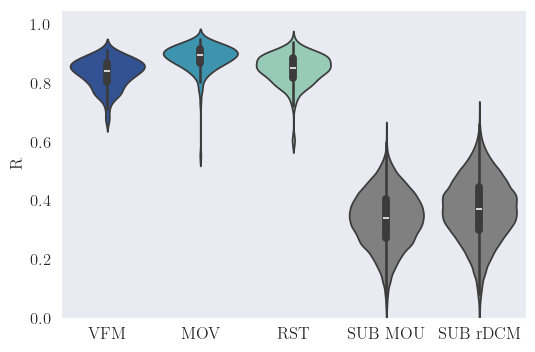

In [116]:
fig, ax = plt.subplots(figsize=(6,4))
sb.violinplot(data=df_alignment, x='tag', y='R', hue='tag',
               palette=(cond_colors[0], cond_colors[1], cond_colors[2], 'gray', 'gray'), ax=ax)
ax.set_xlabel('')
ax.set_ylim((0.0, 1.05))
fig.savefig('comp_R2')

## Within and across model task classification

In [117]:
X_mou = EC_normed_MOU.reshape((3*156,24*24))
X_dcm = EC_normed_rDCM.reshape((3*156,24*24))

y = np.repeat(np.arange(3).reshape(3,1),156,axis=1).reshape((3*156))

gp_sub =  np.repeat(np.arange(156).reshape(1,156),3,axis=0).reshape((3*156))

print(np.repeat(np.arange(3).reshape(3,1),4,axis=1))
print(np.repeat(np.arange(4).reshape(1,4),3,axis=0))

print('X mou : ', X_mou.shape)

[[0 0 0 0]
 [1 1 1 1]
 [2 2 2 2]]
[[0 1 2 3]
 [0 1 2 3]
 [0 1 2 3]]
X mou :  (468, 576)


### Classifier Setup and Training

In [118]:
# Classifiers (with reproducible random_state)
clf_MLR = Pipeline([('std', StandardScaler()),
                    ('mlr', LogisticRegression(penalty='l2', solver='lbfgs', max_iter=500, random_state=0))])

# Map short names to estimators
dict_clf = {
    'MLR': clf_MLR,
#    'RF' : clf_RF
}

# Per-classifier hyperparameter grids for GridSearchCV
dict_params = {
    'mlr__C': [0.01, 0.1, 1.0, 10.0, 100.0],
#    'n_estimators': [10, 50, 100],
#    'criterion': ['gini', 'entropy']
}

In [174]:
# outer cross-validation scheme: 80% for training and 20% for testing
n_splits = 50
#cvs = StratifiedShuffleSplit(n_splits=n_splits, test_size=0.2)
# MG: now done by hand to prevent subject from being in train and test sets

# nested cross-validation scheme
n_split_nest = 5
cv_nest = StratifiedKFold(n_splits=n_split_nest)

# indices for all samples when flattening matrix (cond, sub)
all_sample_ind = np.arange(n_cond*n_sub).reshape((n_cond,n_sub))

In [199]:
def cross_val_train_test(clf, k, param_name, param_vals, X, y):
    # store results
    df_res = pd.DataFrame()
    n_cat = len(np.unique(y))
    cm = np.zeros((n_cat,n_cat))

    # repeat classification
    for _ in range(n_splits):

        sub_train = np.zeros((n_sub), dtype=bool)
        while np.sum(sub_train) < 0.2 * n_sub:
            sub_train[np.random.randint(n_sub)] = True
        sub_test = np.logical_not(sub_train)
        train_ind = all_sample_ind[:,sub_train].flatten()
        test_ind = all_sample_ind[:,sub_test].flatten()

        # grid search for hyperparameter C
        gscv = GridSearchCV(clf,
                    {param_name: param_vals},
                    cv=cv_nest)
        gscv.fit(X[train_ind,:], y[train_ind])
        best_clf = gscv.best_estimator_
        print(gscv.best_params_)

        # train and test best classifier with subject labels
        best_clf.fit(X[train_ind,:], y[train_ind])
        # train and test accuracies
        d = {'type': ['train'],
             'clf': [k],
             'score': [best_clf.score(X[train_ind,:], y[train_ind])]}
        df_res = pd.concat((df_res, pd.DataFrame(data=d)), ignore_index=True)
        d = {'type': ['test'],
             'clf': [k],
             'score': [best_clf.score(X[test_ind,:], y[test_ind])]}
        df_res = pd.concat((df_res, pd.DataFrame(data=d)), ignore_index=True)

        # Add confusion matrix for this specific classifier
        cm += confusion_matrix(y[test_ind], best_clf.predict(X[test_ind,:]))

        # shuffling labels and fit again for evaluation of chance level
        train_ind_rand = np.random.permutation(train_ind)
        best_clf.fit(X[train_ind,:], y[train_ind_rand])
        d = {'type': ['shuf'],
             'clf': [k],
             'score': [best_clf.score(X[test_ind,:], y[test_ind])]}
        df_res = pd.concat((df_res, pd.DataFrame(data=d)), ignore_index=True)

    return df_res, cm

In [206]:
X = X_mou
X /= X.std()

# to store result accuracies and confusion matrix
df_acc_MOU = pd.DataFrame()
dict_cm = {}

# loop over classifiers
for i, (k, param_name) in enumerate(zip(dict_clf,dict_params)):
    # get classifier and related information
    clf = dict_clf[k]
    param_vals = dict_params[param_name]
    # print(param_name, param_vals)

    df_acc_tmp, cm_tmp = cross_val_train_test(clf, k, param_name, param_vals, X, y)
    if k == 'MLR':
        dict_cm['MOU'] = cm_tmp
    df_acc_MOU = pd.concat((df_acc_MOU, df_acc_tmp), ignore_index=True)

# print table of results
print(df_acc_MOU)

print(dict_cm['MOU'])

{'mlr__C': 0.01}
{'mlr__C': 10.0}
{'mlr__C': 10.0}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 100.0}
{'mlr__C': 0.1}
{'mlr__C': 0.1}
{'mlr__C': 10.0}
{'mlr__C': 1.0}
{'mlr__C': 0.01}
{'mlr__C': 100.0}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 10.0}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 10.0}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 1.0}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 1.0}
{'mlr__C': 0.01}
{'mlr__C': 10.0}
{'mlr__C': 1.0}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 10.0}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 1.0}
{'mlr__C': 10.0}
{'mlr__C': 100.0}
{'mlr__C': 0.1}
{'mlr__C': 10.0}
{'mlr__C': 0.01}
      type  clf     score
0    train  MLR  1.000000
1     test  MLR  0.897849
2     shuf  MLR  0.338710
3    train  MLR  1.000000
4     test  MLR  0.908602
..   

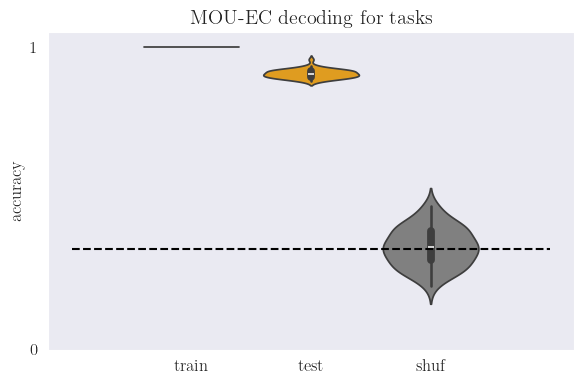

In [207]:
# theoretical chance level
chance_level = 1/3

fig, ax = plt.subplots(figsize=(6,4))
sb.violinplot(data=df_acc_MOU, x='type', y='score', hue='type',
              density_norm='width', palette=['brown','orange','grey'], ax=ax)
ax.plot([-1,3], [chance_level]*2, '--k')
ax.set_yticks([0,1])
ax.set_xlabel('')
ax.set_ylabel('accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('MOU-EC decoding for tasks')
fig.tight_layout()

In [209]:
X = X_dcm
X /= X.std()

# to store result accuracies
df_acc_rDCM = pd.DataFrame()

# loop over classifiers
for i, (k, param_name) in enumerate(zip(dict_clf,dict_params)):
    # get classifier and related information
    clf = dict_clf[k]
    param_vals = dict_params[param_name]
    # print(param_name, param_vals)

    df_acc_tmp, cm_tmp = cross_val_train_test(clf, k, param_name, param_vals, X, y)
    if k == 'MLR':
        dict_cm['rDCM'] = cm_tmp
    df_acc_rDCM = pd.concat((df_acc_rDCM, df_acc_tmp), ignore_index=True)

# print table of results
print(df_acc_rDCM)

print(dict_cm['rDCM'])

{'mlr__C': 0.01}
{'mlr__C': 1.0}
{'mlr__C': 0.01}
{'mlr__C': 10.0}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 10.0}
{'mlr__C': 0.1}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 1.0}
{'mlr__C': 100.0}
{'mlr__C': 10.0}
{'mlr__C': 0.1}
{'mlr__C': 1.0}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 10.0}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 0.1}
{'mlr__C': 0.1}
{'mlr__C': 0.1}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 10.0}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 10.0}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 10.0}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 1.0}
{'mlr__C': 0.1}
{'mlr__C': 1.0}
{'mlr__C': 10.0}
{'mlr__C': 0.01}
      type  clf     score
0    train  MLR  1.000000
1     test  MLR  0.948925
2     shuf  MLR  0.322581
3    train  MLR  1.000000
4     test  MLR  0.940860
..     ...  ..

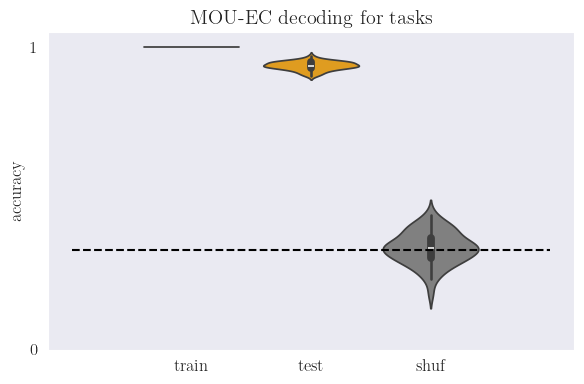

In [210]:
# plot: train versus test accuracy
# theoretical chance level
chance_level = 0.33

fig, ax = plt.subplots(figsize=(6,4))
sb.violinplot(data=df_acc_rDCM, x='type', y='score', hue='type',
              density_norm='width', palette=['brown','orange','grey'], ax=ax)
ax.plot([-1,3], [chance_level]*2, '--k')
ax.set_yticks([0,1])
ax.set_xlabel('')
ax.set_ylabel('accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('MOU-EC decoding for tasks')
fig.tight_layout()


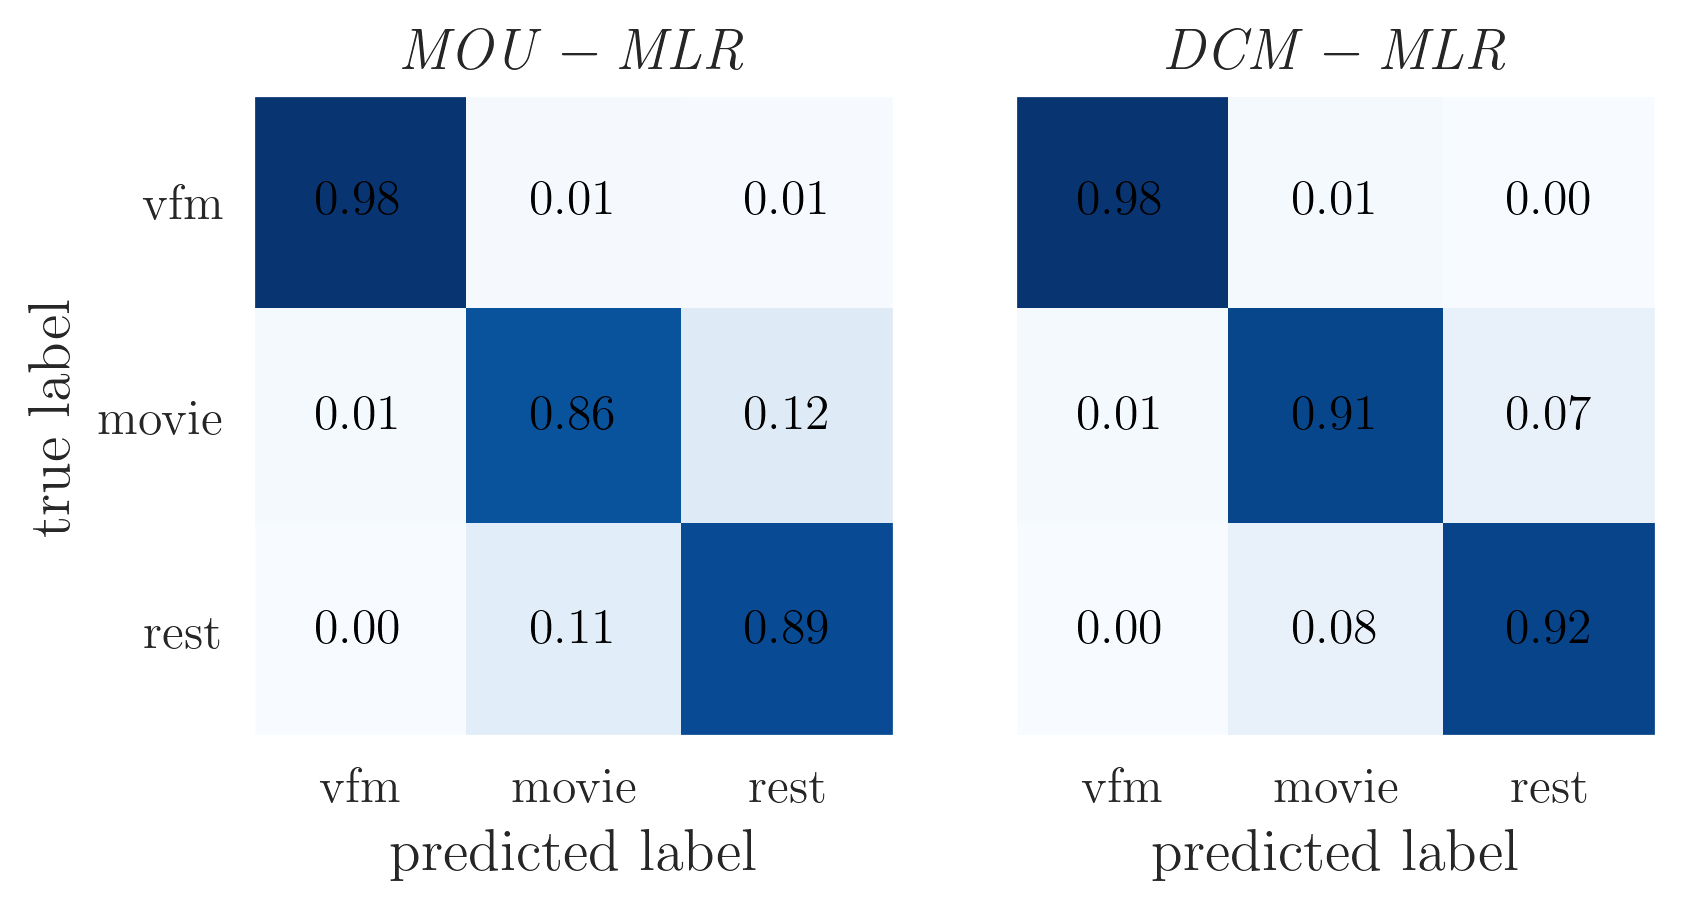

In [214]:
cm_MOU = dict_cm['MOU'] / np.sum(dict_cm['MOU'], axis=1, keepdims=True)
cm_rDCM = dict_cm['rDCM'] / np.sum(dict_cm['rDCM'], axis=1, keepdims=True)

fig, ax = plt.subplots(1, 2, figsize=(6, 3), dpi=300, facecolor="w")  # Changed to 1x2 grid

# Left: MOU MLR
im1 = ax[0].imshow(cm_MOU, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
ax[0].set_ylabel('true label', fontsize=14, weight='bold')
ax[0].set_xlabel('predicted label', fontsize=14, weight='bold')  # Added xlabel
ax[0].set_title(r'$\mathit{MOU - MLR}$', fontsize=14)
ax[0].set_xticks(range(3))
ax[0].set_xticklabels(['vfm','movie','rest'], fontsize=12)
ax[0].set_yticks(range(3))
ax[0].set_yticklabels(['vfm','movie','rest'], fontsize=12)

# Add text annotations for MOU MLR
for i in range(3):
    for j in range(3):
        text = ax[0].text(j, i, f'{cm_MOU[i, j]:.2f}',
                           ha="center", va="center", color="black", fontweight='bold')

# Right: DCM MLR
im2 = ax[1].imshow(cm_rDCM, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
ax[1].set_xlabel('predicted label', fontsize=14, weight='bold')  # Added xlabel
ax[1].set_title(r'$\mathit{DCM - MLR}$', fontsize=14)
ax[1].set_xticks(range(3))
ax[1].set_xticklabels(['vfm','movie','rest'], fontsize=12)
ax[1].set_yticks(range(3))
ax[1].set_yticklabels([''] * 3)  # Remove y-axis labels

# Add text annotations for DCM MLR
for i in range(3):
    for j in range(3):
        text = ax[1].text(j, i, f'{cm_rDCM[i, j]:.2f}',
                           ha="center", va="center", color="black", fontweight='bold')

# Make frame thicker for all subplots
for i in range(2):
    for spine in ax[i].spines.values():
        spine.set_linewidth(1.5)
    ax[i].tick_params(labelsize=12)

fig.tight_layout()

#fig.savefig(output_fig_pth / '/confMat_MOU_DCM_comparison_no_cbar.svg', transparent=None, dpi='figure', format='svg',
#    facecolor='auto', edgecolor='auto', bbox_inches='tight')


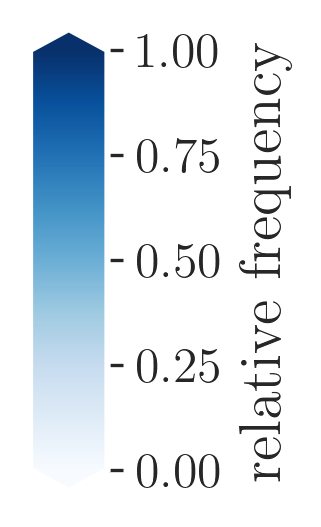

In [216]:
import matplotlib.colorbar as cbar
import matplotlib.colors as mcolors

# Set font configuration to match the main figure
plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'

# Create a standalone figure for the colorbar
fig, ax = plt.subplots(figsize=(1/3, 6/3), dpi=300, facecolor="w")  # Narrow and tall for vertical bar

# Create a dummy colormap and normalization to match the main figure
cmap = plt.cm.Blues
norm = mcolors.Normalize(vmin=0, vmax=1)

# Create the colorbar using ColorbarBase
cb = cbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical', extend='both')
cb.ax.tick_params(labelsize=12)  # Match tick font size
cb.set_label('relative frequency', fontsize=14, weight='bold')  # Match label font size and weight

# Add edges (border) to the colorbar for scientific paper style
ax.set_frame_on(True)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)  # Match the frame thickness from the main figure

# Save the standalone colorbar figure
#plt.savefig(output_fig_pth / '/standalone_colorbar_with_edges.svg', transparent=None, dpi='figure', format='svg',
#    facecolor='auto', edgecolor='auto', bbox_inches='tight')


## Cross-decoding between MOU and rDCM

Alignment between MOU and rDCM through cross learning.

In [217]:
def cross_val_transfer(clf, k, param_name, param_vals, X_src, tag_src, X_tgt, tag_tgt, y):
    # store results
    df_res = pd.DataFrame()
    n_cat = len(np.unique(y))
    cm = np.zeros((n_cat,n_cat))

    # repeat classification
    for _ in range(n_splits):

        sub_train = np.zeros((n_sub), dtype=bool)
        while np.sum(sub_train) < 0.2 * n_sub:
            sub_train[np.random.randint(n_sub)] = True
        sub_test = np.logical_not(sub_train)
        train_ind = all_sample_ind[:,sub_train].flatten()
        test_ind = all_sample_ind[:,sub_test].flatten()

        # grid search for hyperparameter C
        gscv = GridSearchCV(clf,
                    {param_name: param_vals},
                    cv=cv_nest)
        gscv.fit(X[train_ind,:], y[train_ind])
        best_clf = gscv.best_estimator_
        print(gscv.best_params_)

        # train and test best classifier with subject labels
        best_clf.fit(X_src[train_ind,:], y[train_ind])
        # accuracies
        d = {'type': ['test\n' + tag_src],
             'clf': [k],
             'score': [best_clf.score(X_src[test_ind,:], y[test_ind])]}
        df_res = pd.concat((df_res, pd.DataFrame(data=d)), ignore_index=True)
        d = {'type': ['test\n' + tag_tgt],
             'clf': [k],
             'score': [best_clf.score(X_tgt[test_ind,:], y[test_ind])]}
        df_res = pd.concat((df_res, pd.DataFrame(data=d)), ignore_index=True)

        cm += confusion_matrix(y[test_ind], best_clf.predict(X_tgt[test_ind,:]))

        # shuffling labels and fit again for evaluation of chance level
        train_ind_rand = np.random.permutation(train_ind)
        best_clf.fit(X_src[train_ind,:], y[train_ind_rand])
        d = {'type': ['shuf'],
             'clf': [k],
             'score': [best_clf.score(X_tgt[test_ind,:], y[test_ind])]}
        df_res = pd.concat((df_res, pd.DataFrame(data=d)), ignore_index=True)

    return df_res, cm

In [220]:
# cross learning
#from sklearn.preprocessing import MinMaxScaler
#X_ref = MinMaxScaler().fit_transform(X_dcm)
#X_tgt = MinMaxScaler().fit_transform(X_mou)

# loop over classifiers
for i, (k, param_name) in enumerate(zip(dict_clf,dict_params)):
    # get classifier and related information
    clf = dict_clf[k]
    param_vals = dict_params[param_name]
    # print(param_name, param_vals)

    df_acc_tmp, cm = cross_val_transfer(clf, k, param_name, param_vals, X_dcm, 'rDCM', X_mou, 'MOU', y)

df_acc_rDCM_to_MOU = df_acc_tmp

{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 0.1}
{'mlr__C': 100.0}
{'mlr__C': 1.0}
{'mlr__C': 0.1}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 1.0}
{'mlr__C': 0.1}
{'mlr__C': 1.0}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 1.0}
{'mlr__C': 1.0}
{'mlr__C': 1.0}
{'mlr__C': 10.0}
{'mlr__C': 0.1}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 10.0}
{'mlr__C': 100.0}
{'mlr__C': 10.0}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 100.0}
{'mlr__C': 0.1}
{'mlr__C': 100.0}
{'mlr__C': 0.01}
{'mlr__C': 1.0}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 1.0}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 100.0}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 1.0}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 10.0}
{'mlr__C': 0.01}
{'mlr__C': 1.0}
{'mlr__C': 0.1}
{'mlr__C': 1.0}


In [221]:
## loop over classifiers
for i, (k, param_name) in enumerate(zip(dict_clf,dict_params)):
    # get classifier and related information
    clf = dict_clf[k]
    param_vals = dict_params[param_name]
    # print(param_name, param_vals)

    df_acc_tmp, cm = cross_val_transfer(clf, k, param_name, param_vals, X_mou, 'MOU', X_dcm, 'rDCM', y)

df_acc_MOU_to_rDCM = df_acc_tmp

{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 1.0}
{'mlr__C': 10.0}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 10.0}
{'mlr__C': 0.1}
{'mlr__C': 0.1}
{'mlr__C': 1.0}
{'mlr__C': 0.01}
{'mlr__C': 1.0}
{'mlr__C': 100.0}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 10.0}
{'mlr__C': 1.0}
{'mlr__C': 10.0}
{'mlr__C': 0.1}
{'mlr__C': 1.0}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 10.0}
{'mlr__C': 0.1}
{'mlr__C': 1.0}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 0.1}
{'mlr__C': 1.0}
{'mlr__C': 0.1}
{'mlr__C': 0.01}
{'mlr__C': 0.01}
{'mlr__C': 10.0}
{'mlr__C': 0.01}
{'mlr__C': 100.0}
{'mlr__C': 10.0}
{'mlr__C': 10.0}
{'mlr__C': 0.01}
{'mlr__C': 1.0}


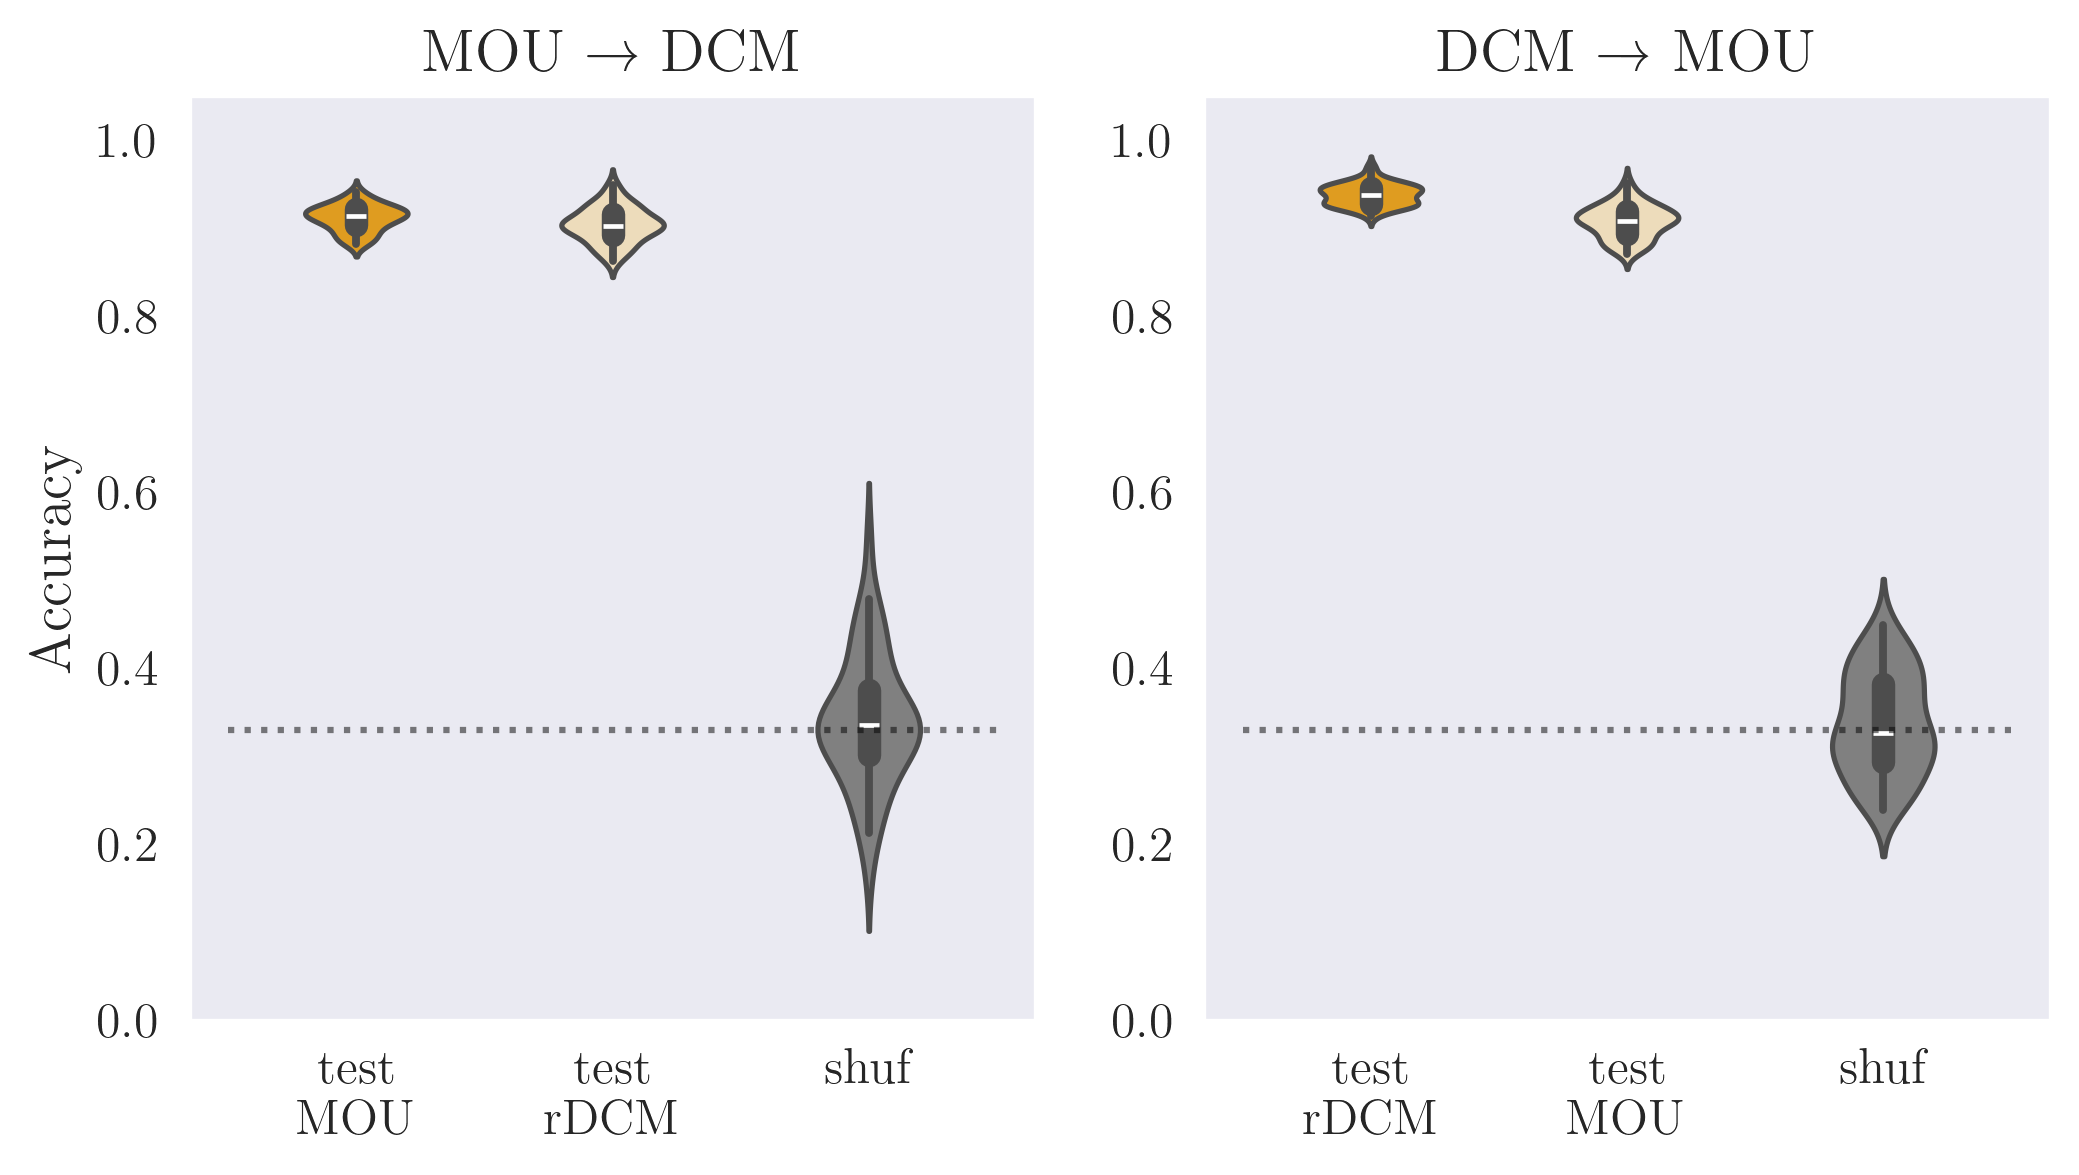

In [224]:
chance_level = 0.33

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300, facecolor="w")

# Model fit
sb.violinplot(data=df_acc_MOU_to_rDCM, y='score', x='type', hue='type', density_norm='width', width=0.4, palette=['orange', 'wheat', 'grey'], ax=axs[0])
axs[0].plot([-0.5, 2.5], [chance_level]*2, ':k', alpha=0.5)
axs[0].set_ylabel('Accuracy', fontsize=14, weight='bold')
axs[0].set_xlabel('')
axs[0].set_ylim(0.0, 1.05)
axs[0].set_title(u'MOU \u2192 DCM')

sb.violinplot(data=df_acc_rDCM_to_MOU, y='score', x='type', hue='type', density_norm='width', width=0.4, palette=['orange', 'wheat', 'grey'], ax=axs[1])
axs[1].plot([-0.5, 2.5], [chance_level]*2, ':k', alpha=0.5)
axs[1].set_ylabel('', fontsize=14, weight='bold')
axs[1].set_xlabel('')
axs[1].set_ylim(0.0, 1.05)
axs[1].set_title(u'DCM \u2192 MOU')

#ax.tick_params(axis='y', labelsize=12)


plt.savefig(output_fig_pth / 'transferLearning_MOU-rDCM.svg', transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto', bbox_inches='tight')

## WHY NEED SCALING BY STD TO GET GOOD CROSS DECODING PERF?????!!!!!?????

## Feature importance detection

In [ ]:
# rois_sorted = [
#         'V1 vf',
#         'V1 vp',
#         'V1 df', 
#         'V1 dp',
#         'V2 vf',
#         'V2 vp',
#         'V2 df', 
#         'V2 dp',
#         'V3 vf',
#         'V3 vp',
#         'V3 df', 
#         'V3 dp',
#         'V1 vf',
#         'V1 vp',
#         'V1 df', 
#         'V1 dp',
#         'V2 vf',
#         'V2 vp',
#         'V2 df', 
#         'V2 dp',
#         'V3 vf',
#         'V3 vp',
#         'V3 df', 
#         'V3 dp']



### MOU features

In [ ]:
# quick fix to get coefficients from mlr estimator in pipeline
def get_coef(clf):
    return clf['mlr'].coef_  # repeat classification

clf = dict_clf['MLR'] # MLR
print(clf)

In [125]:

rkgs_MOU = np.zeros((cvs.get_n_splits(), 24**2))

i_rep = 0
for train_ind, test_ind in cvs.split(X_mou, y):

    # wrap classifier to be fitted to data to calculate the ranking
    feature_select = RFE(clf, n_features_to_select=10, step=10,
                         importance_getter=get_coef)

    # perform RFE
    feature_select.fit(X_mou[train_ind,:], y[train_ind])
    rkgs_MOU[i_rep,:] = feature_select.ranking_
    i_rep += 1

Pipeline(steps=[('std', StandardScaler()),
                ('mlr', LogisticRegression(max_iter=500, random_state=0))])


In [137]:
mean_rkg = np.mean(rkgs_MOU, axis=0)

#print(np.argsort(mean_rkg))

i_roi = np.repeat(np.arange(24).reshape(-1,1), 24, axis=1).flatten()
j_roi = np.repeat(np.arange(24).reshape(1,-1), 24, axis=0).flatten()

mask_info_feat = np.zeros((24,24))
for ii in np.argsort(mean_rkg)[:30]:
    print(f'from {roi_labels_sorted[i_roi[ii]]} to {roi_labels_sorted[j_roi[ii]]}')
    mask_info_feat[i_roi[ii], j_roi[ii]] = 1

mask_info_feat_MOU = mask_info_feat

from V1 vp to V1 vp
from V1 vp to V2 vf
from V1 dp to V1 dp
from V2 vf to V1 vp
from V1 vp to V2 vf
from V1 vp to V2 vf
from V2 vf to V2 vf
from V1 dp to V2 vf
from V1 vp to V1 vp
from V1 vp to V2 df
from V3 dp to V1 vp
from V1 vp to V2 df
from V2 df to V1 vp
from V2 vf to V1 vp
from V1 dp to V2 vf
from V2 vf to V2 vf
from V3 vp to V2 dp
from V1 dp to V1 dp
from V1 vp to V2 dp
from V3 vp to V3 vp
from V1 vp to V2 vf
from V2 df to V1 vp
from V2 df to V1 dp
from V1 dp to V3 dp
from V3 vp to V2 vf
from V3 dp to V1 vp
from V3 dp to V3 dp
from V2 vf to V3 vp
from V3 vp to V3 vp
from V1 df to V2 df


In [73]:
# Save the EC ferature ranking arrays
save_path = "/home/nicolas/Documents/GitHubProjects/retNet/docs_local/source/notebooks/"

np.save(os.path.join(save_path, 'rkgs_MOU.npy'), rkgs_MOU)

print(f"Saved rkgs_MOU.npy with shape: {rkgs_MOU.shape}")


Saved rkgs_MOU.npy with shape: (50, 576)


### rDCM features

In [128]:

rkgs_rDCM = np.zeros((cvs.get_n_splits(), 24**2))

i_rep = 0
for train_ind, test_ind in cvs.split(X_dcm, y):
    
    # wrap classifier to be fitted to data to calculate the ranking
    feature_select = RFE(clf, n_features_to_select=10, step=10,
                         importance_getter=get_coef)
    
    # perform RFE
    feature_select.fit(X_dcm[train_ind,:], y[train_ind])
    rkgs_rDCM[i_rep,:] = feature_select.ranking_
    i_rep += 1

In [136]:
mean_rkg = np.mean(rkgs_rDCM, axis=0)

#print(np.argsort(mean_rkg))

i_roi = np.repeat(np.arange(24).reshape(-1,1), 24, axis=1).flatten()
j_roi = np.repeat(np.arange(24).reshape(1,-1), 24, axis=0).flatten()

mask_info_feat = np.zeros((24,24))
for ii in np.argsort(mean_rkg)[:30]:
    print(f'from {roi_labels_sorted[i_roi[ii]]} to {roi_labels_sorted[j_roi[ii]]}')
    mask_info_feat[i_roi[ii], j_roi[ii]] = 1



mask_info_feat_rDCM = mask_info_feat

from V1 vp to V2 vf
from V2 vf to V1 vp
from V1 vp to V2 vf
from V1 vp to V2 vf
from V2 vf to V3 vp
from V1 dp to V1 dp
from V1 vp to V1 vp
from V3 vp to V2 vf
from V2 vf to V2 vf
from V1 vp to V2 vf
from V3 vp to V3 vp
from V1 dp to V3 dp
from V1 dp to V2 vf
from V2 vp to V3 vp
from V1 vp to V1 vp
from V3 vp to V1 df
from V1 vp to V2 df
from V1 dp to V2 df
from V1 dp to V3 dp
from V3 vp to V3 df
from V3 vp to V2 vf
from V3 vp to V1 df
from V2 vp to V3 vp
from V1 vp to V2 df
from V3 vp to V1 vf
from V3 df to V3 vp
from V1 dp to V1 dp
from V1 vp to V3 df
from V3 vp to V2 vf
from V2 vf to V1 vp


In [76]:
# Save the EC ferature ranking arrays
save_path = "/home/nicolas/Documents/GitHubProjects/retNet/docs_local/source/notebooks/"

np.save(os.path.join(save_path, 'rkgs_rDCM.npy'), rkgs_rDCM)

print(f"Saved rkgs_rDCM.npy with shape: {rkgs_rDCM.shape}")


Saved rkgs_rDCM.npy with shape: (50, 576)


PearsonRResult(statistic=np.float64(0.734434531655361), pvalue=np.float64(1.0746597443575293e-98))


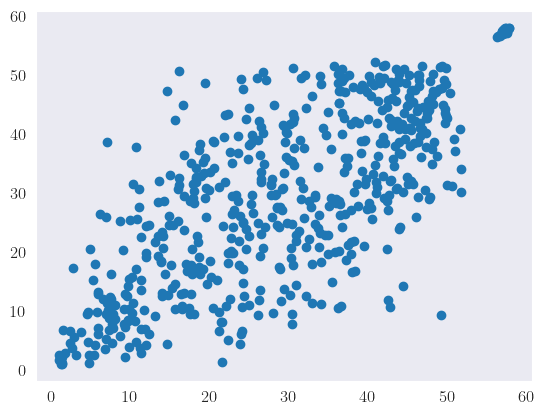

In [135]:
plt.scatter(rkgs_MOU.mean(0), rkgs_rDCM.mean(0))

print(stt.pearsonr(rkgs_MOU.mean(0), rkgs_rDCM.mean(0)))

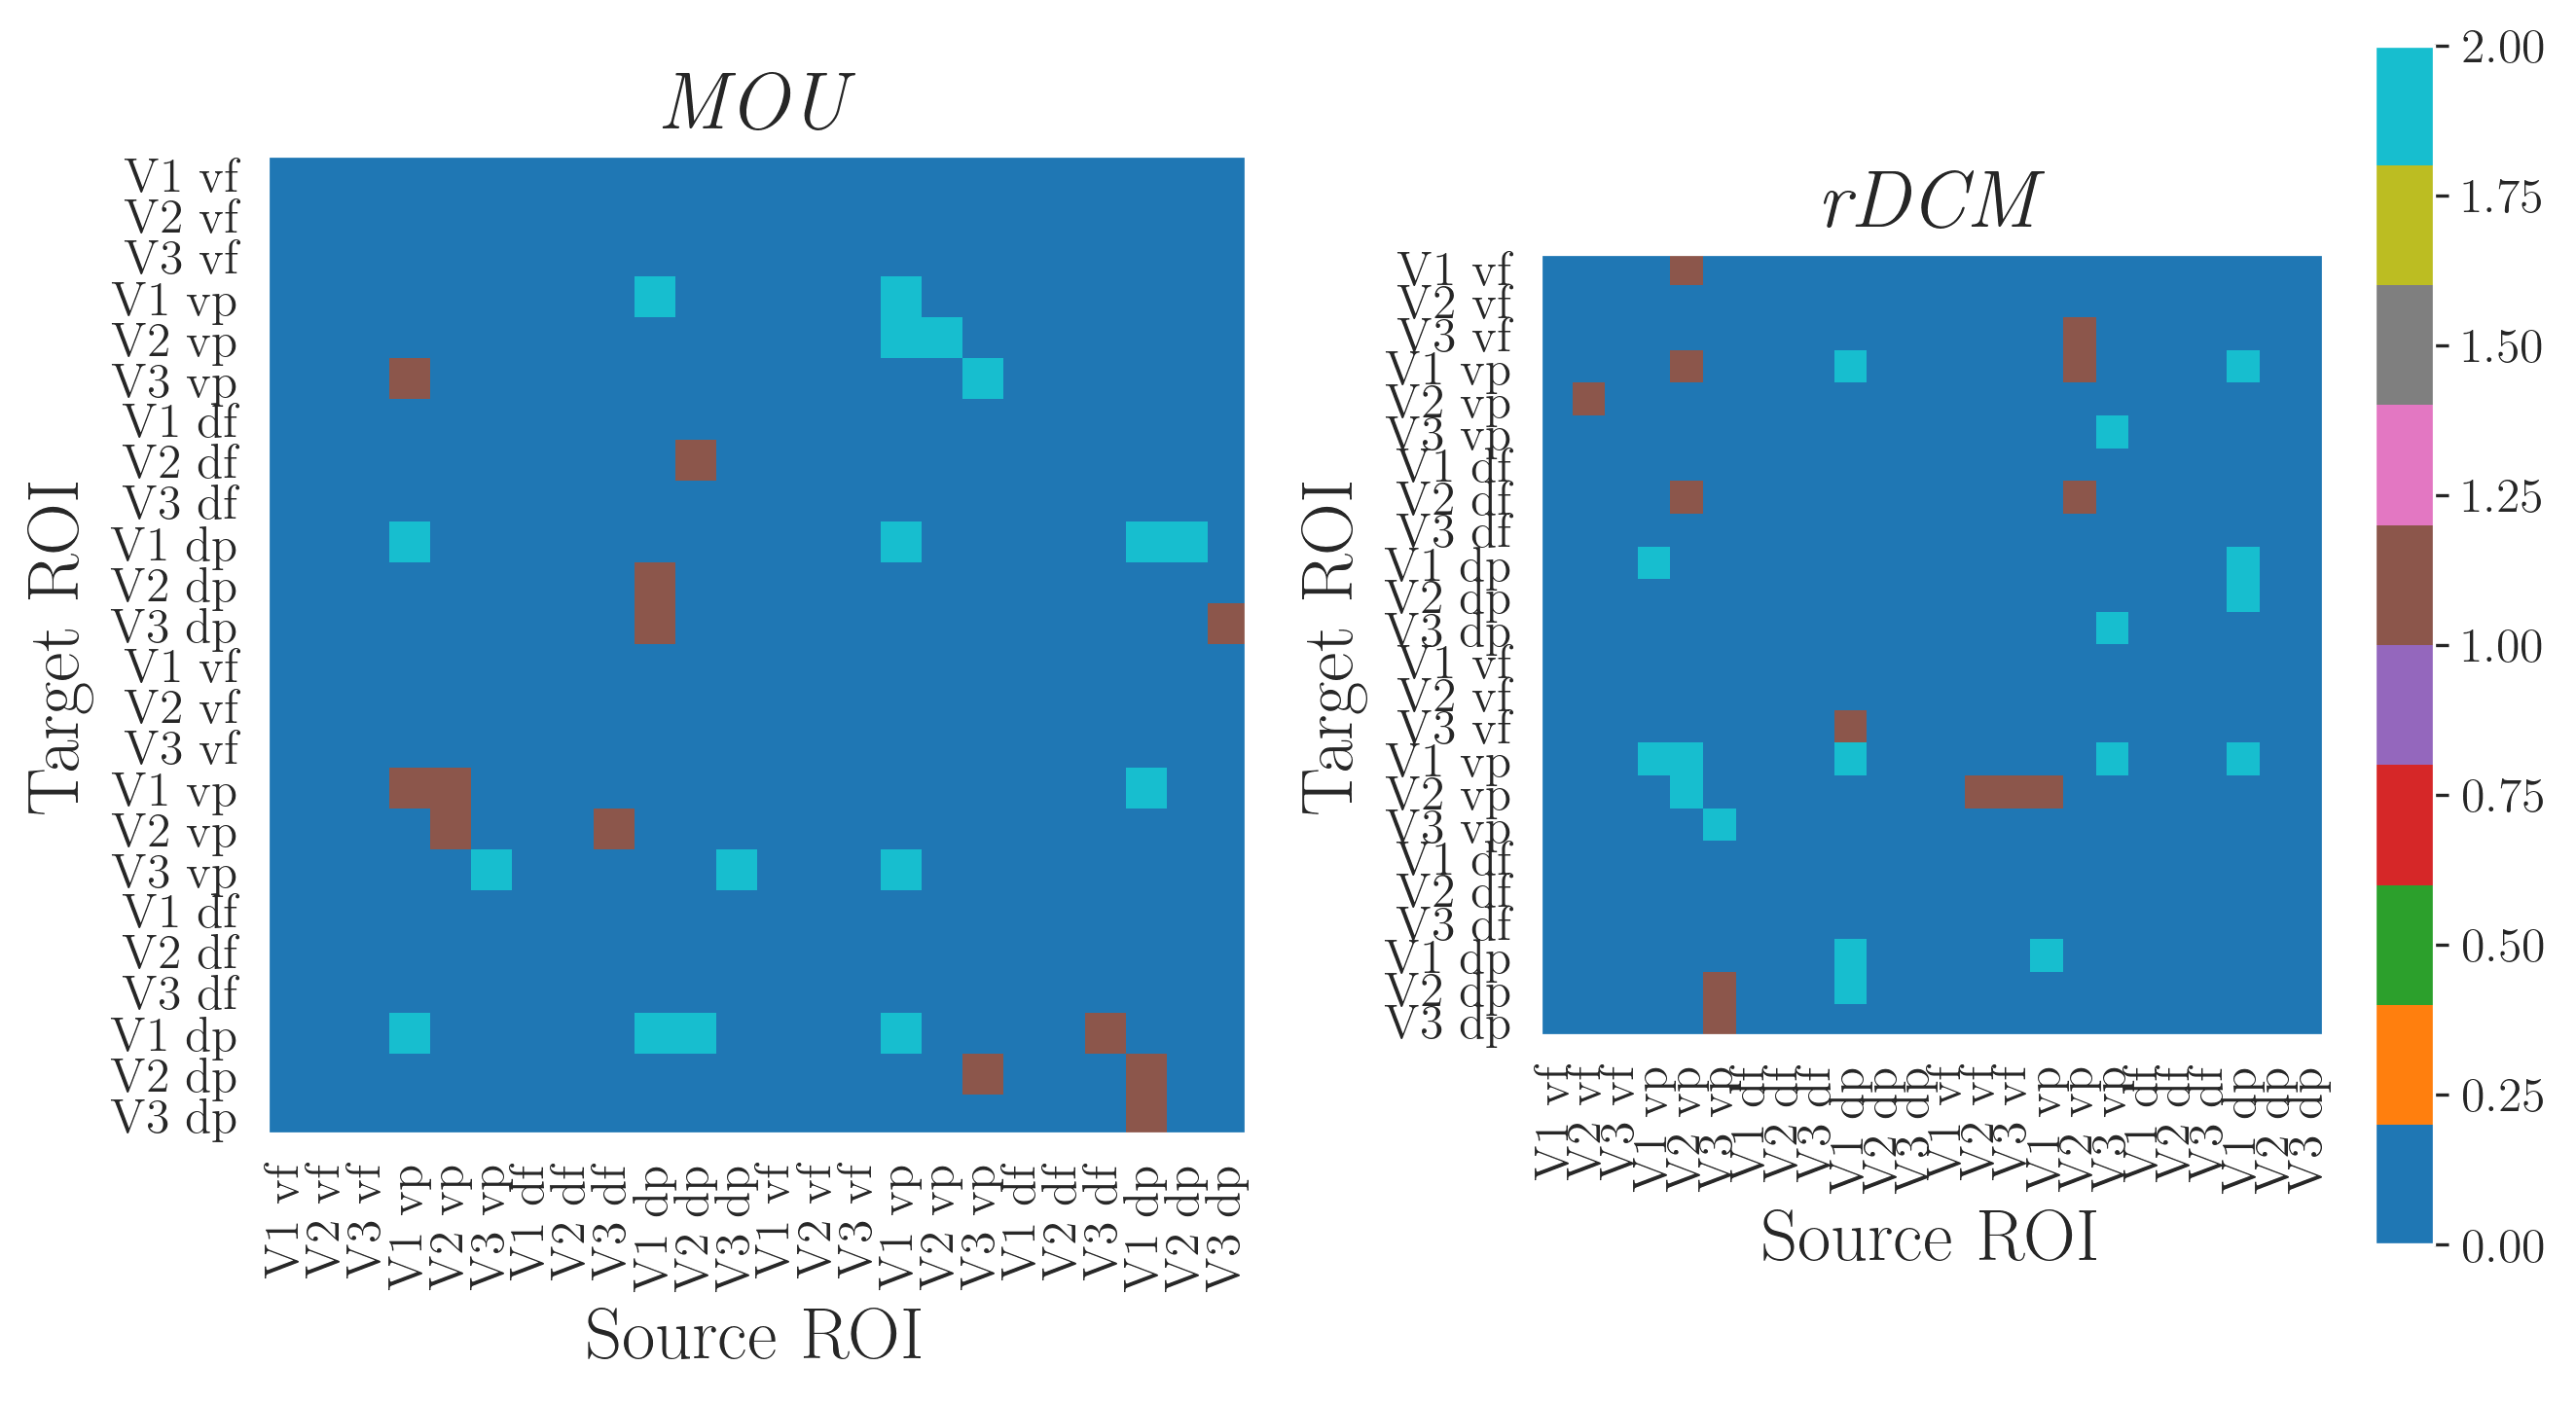

In [142]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(1, 2, figsize=(9, 5), dpi=300, facecolor="w")

EC_max = 2

mask_info_feat_common = mask_info_feat_MOU * mask_info_feat_rDCM

# MOU plot
mask_aff = mask_info_feat_MOU + mask_info_feat_common
im_vfm = ax[0].imshow(mask_aff[np.ix_(new_order, new_order)], vmin=0, vmax=EC_max, cmap='tab10')
ax[0].set_xlabel('Source ROI', fontsize=18, weight='bold')
ax[0].set_xticks(np.arange(len(roi_labels_sorted)))
ax[0].set_xticklabels(labels=roi_labels_sorted, rotation=90, fontsize=12)
ax[0].set_ylabel('Target ROI', fontsize=18, weight='bold')
ax[0].set_yticks(np.arange(len(roi_labels_sorted)))
ax[0].set_yticklabels(labels=roi_labels_sorted, rotation=0, fontsize=12)
ax[0].set_title(r'$\mathit{MOU}$', fontsize=20)

# rDCM plot
mask_aff = mask_info_feat_rDCM + mask_info_feat_common
im_rs = ax[1].imshow(mask_aff.T[np.ix_(new_order, new_order)], vmin=0, vmax=EC_max, cmap='tab10')
ax[1].set_xlabel('Source ROI', fontsize=18, weight='bold')
ax[1].set_xticks(np.arange(len(roi_labels_sorted)))
ax[1].set_xticklabels(labels=roi_labels_sorted, rotation=90, fontsize=12)
ax[1].set_ylabel('Target ROI', fontsize=18, weight='bold')
ax[1].set_yticks(np.arange(len(roi_labels_sorted)))
ax[1].set_yticklabels(labels=roi_labels_sorted, rotation=0, fontsize=12)
ax[1].set_title(r'$\mathit{rDCM}$', fontsize=20)

fig.colorbar(im_rs, ax=ax[1])

# Make frame thicker for both subplots
for a in ax:
    for spine in a.spines.values():
        spine.set_linewidth(1.5)

plt.tight_layout()

# Save as SVG
#plt.savefig(output_fig_pth / 'best.svg', transparent=None, dpi='figure', format='svg',
#    facecolor='auto', edgecolor='auto', bbox_inches='tight')
